# Lab 2 — Baseline com múltiplos datasets

Neste notebook vamos rodar o mesmo pipeline de baseline para 4 datasets diferentes.

A ideia é simples: para cada dataset na lista `keys_to_run`, o código vai:
1. baixar e carregar os dados
2. limpar valores ausentes e aplicar `dropna` antes do split
3. treinar dois modelos baseline (um linear e um de floresta)
4. imprimir as métricas e salvar os resultados

No final, uma tabela compara os melhores modelos de cada dataset.

In [1]:
# 1) Bibliotecas
from __future__ import annotations

import json
import zipfile
from pathlib import Path
from urllib.request import urlretrieve

from namex import export
import numpy as np
import pandas as pd
import pyarrow
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from lightgbm import LGBMClassifier, LGBMRegressor
#CatBoost
from catboost import CatBoostClassifier, CatBoostRegressor
import db_dtypes


In [2]:
# 2) Metadados dos datasets e funcoes  que nos ajudam a baixar, extrair e normalizar os dados

DATASETS = {
    "adult": {"task": "classification", "target": "income"},
    "bank_marketing": {"task": "classification", "target": "y"},
    "air_quality_uci": {"task": "regression", "target": "C6H6(GT)"},
    "communities_crime": {"task": "regression", "target": "ViolentCrimesPerPop"},
    "cnpq_bolsas": {"task": "classification", "target": "grande_area_conhecimento"},
}

# Tokens que representam valores ausentes
NUMERIC_MISSING_VALUES = [-200, -200.0]

STRING_MISSING_VALUES = [
    "?", " ?", "? ", "NA", "N/A", "na", "n/a", "NaN", "nan", "", " ",
    "unknown", "Unknown", "-200",
]


def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def download_file(url: str, output_path: Path) -> Path:
    supress_output = True

    output_path.parent.mkdir(parents=True, exist_ok=True)
    if not output_path.exists():
        print(f"[download] {url}")
        urlretrieve(url, output_path)
    elif not supress_output:
        print(f"[cache] {output_path}")
    return output_path


def unzip_file(zip_path: Path, extract_dir: Path) -> Path:
    supress_output = True

    extract_dir.mkdir(parents=True, exist_ok=True)
    marker = extract_dir / ".extracted"
    if not marker.exists():
        print(f"[extract] {zip_path}")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)
        marker.write_text("ok\n", encoding="utf-8")
    elif not supress_output:
        print(f"[cache] {extract_dir}")
    return extract_dir


def normalize_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """Substitui tokens de missing por NaN, coluna a coluna, respeitando o dtype.
    
    - Colunas numericas: substitui -200 e -200.0
    - Colunas de texto: faz strip e substitui tokens como '?', 'unknown', etc.
    Essa abordagem evita erros do pandas 2.x ao misturar int e str no replace().
    -- TODO: verificar se tem outros simbolos estranhos nos dataset da atividade (pedir par aos alunos checarem isso)
    """
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].replace(NUMERIC_MISSING_VALUES, np.nan)
        else:
            df[col] = df[col].astype("string").str.strip()
            df[col] = df[col].replace(STRING_MISSING_VALUES, pd.NA)
    return df



In [ ]:
def load_cnpq_bolsas(data_dir: Path, sample_size: int = 10000) -> tuple[pd.DataFrame, str, str]:
    """Carrega o dataset CNPQ com download e limpeza automática."""
    import pyarrow.parquet as pq
    import gdown
    import os

    file_id = "1kZLrjRr4z1MGx7ehWQHXUcFwgsTqVOIX"

    base = data_dir / "dataset_cnpq_felps"
    base.mkdir(parents=True, exist_ok=True)

    arquivo_path = base / "br_cnpq_bolsas_microdados.parquet"

    # Se o ficheiro não existir ou tiver menos de 1MB (ou seja, for o HTML de erro), faz o download
    if not arquivo_path.exists() or os.path.getsize(arquivo_path) < 1000000:
        if arquivo_path.exists():
            os.remove(arquivo_path)
            
        print("Iniciando o download do ficheiro de 142MB usando gdown...")
        # Usa o id para evitar o bloqueio de antivírus da Google
        gdown.download(id=file_id, output=str(arquivo_path), quiet=False)
        print("Download concluído com sucesso!")

    table = pq.read_table(arquivo_path)
    if table.schema.pandas_metadata:
        table = table.replace_schema_metadata()

    df = table.to_pandas()

    colunas_remover = [
        "fonte_recurso",
        "plano_interno",
        "acao_ppa",
        "programa_ppa",
        "unidade_orcamentaria",
        "natureza_despesa",
        "categoria_nivel",
        "processo",
        "beneficiario",
        #"palavra_chave",
        "data_inicio_processo",
        "data_fim_processo",
    ]

    target = "grande_area_conhecimento"
    task = "classification"

    df = df.drop(columns=[c for c in colunas_remover if c in df.columns], errors="ignore")

    missing_pct = df.isnull().mean()
    high_missing = missing_pct[missing_pct > 0.40].index.tolist()
    high_missing = [c for c in high_missing if c != target]
    if high_missing:
        df = df.drop(columns=high_missing, errors="ignore")

    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].astype("string")

    if sample_size and len(df) > sample_size:
        df = df.sample(sample_size, random_state=42)

    if target not in df.columns:
        raise RuntimeError(f"Target '{target}' nao encontrada apos limpeza.")

    return df, target, task

In [4]:
# 3) Funcoes. para baixar os datasets automaticamente

# fiz alguns pequenos ajustes caso a caso para facilitar a leitura e evitar erros de parsing

def load_adult(data_dir: Path) -> tuple[pd.DataFrame, str, str]:
    base = data_dir / "adult"
    data_file = download_file(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
        base / "adult.data",
    )
    test_file = download_file(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test",
        base / "adult.test",
    )

    columns = [
        "age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
        "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
        "hours_per_week", "native_country", "income",
    ]

    train_df = pd.read_csv(data_file, header=None, names=columns, skipinitialspace=True, na_values=["?", " ?"])
    test_df = pd.read_csv(test_file, header=None, names=columns, skiprows=1, skipinitialspace=True, na_values=["?", " ?"])

    df = pd.concat([train_df, test_df], ignore_index=True)
    df["income"] = df["income"].astype(str).str.replace(".", "", regex=False).str.strip()
    return df, "income", "classification"


def load_bank_marketing(data_dir: Path) -> tuple[pd.DataFrame, str, str]:
    base = data_dir / "bank_marketing"
    zip_path = download_file(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip",
        base / "bank.zip",
    )
    extract_dir = unzip_file(zip_path, base / "extracted")
    df = pd.read_csv(extract_dir / "bank-full.csv", sep=";")
    return df, "y", "classification"


def load_air_quality_uci(data_dir: Path) -> tuple[pd.DataFrame, str, str]:
    base = data_dir / "air_quality_uci"
    zip_path = download_file(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip",
        base / "AirQualityUCI.zip",
    )
    extract_dir = unzip_file(zip_path, base / "extracted")
    candidates = list(extract_dir.rglob("AirQualityUCI.csv"))
    if not candidates:
        raise FileNotFoundError("Nao encontrei AirQualityUCI.csv dentro do zip.")

    df = pd.read_csv(candidates[0], sep=";", decimal=",")
    df = df.dropna(axis=1, how="all").dropna(axis=0, how="all")
    for col in ["Date", "Time"]:
        if col in df.columns:
            df = df.drop(columns=[col])
    return df, "C6H6(GT)", "regression"


def load_communities_crime(data_dir: Path) -> tuple[pd.DataFrame, str, str]:
    base = data_dir / "communities_crime"
    data_file = download_file(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/communities/communities.data",
        base / "communities.data",
    )
    df = pd.read_csv(data_file, header=None, na_values=["?"])

    cols = [f"col_{i}" for i in range(df.shape[1])]
    cols[-1] = "ViolentCrimesPerPop"
    df.columns = cols
    # colunas  com muito problema
    df = df.drop(columns=[c for c in ["col_0", "col_1", "col_2", "col_3", "col_4"] if c in df.columns])
    return df, "ViolentCrimesPerPop", "regression"


def load_dataset(key: str, data_dir: Path) -> tuple[pd.DataFrame, str, str]:
    if key == "adult":
        return load_adult(data_dir)
    if key == "bank_marketing":
        return load_bank_marketing(data_dir)
    if key == "air_quality_uci":
        return load_air_quality_uci(data_dir)
    if key == "communities_crime":
        return load_communities_crime(data_dir)
    if key == "cnpq_bolsas":
        return load_cnpq_bolsas(data_dir)   
    raise ValueError(f"Key desconhecida: {key}")

### Usamos o catboost pensando principalmente nos dados categóricos do cnpq, mas ele fez um grande impacto em outros datasets também, ele é consideravelmente simples de "tunar" e evita o "Prediction Shift" -> (Em datasets como adult ou bank_marketing, onde as relações entre variáveis são complexas, o Boosting tradicional tende a decorar o ruído.)

### O LightGBM serviu como uma exploração inicial do trabalho, já que não teve muito impacto no inicio do projeto e, optamos por não utilizar ele no experimento final.

In [5]:
# 4) Funcoes para separar  treino e teste


def split_X_y(df: pd.DataFrame, target: str) -> tuple[pd.DataFrame, pd.Series]:
    if target not in df.columns:
        raise ValueError(f"Target '{target}' nao esta no dataset.")
    return df.drop(columns=[target]), df[target]


def build_preprocessor(X: pd.DataFrame, scale_numeric: bool) -> ColumnTransformer:
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler() if scale_numeric else "passthrough", numeric_cols),
            ("cat", make_one_hot_encoder(), categorical_cols),
        ],
        remainder="drop",
    )


def make_class_weights(y: pd.Series) -> dict:
    counts = y.value_counts(dropna=False)
    total = float(counts.sum())
    n_classes = float(len(counts))
    return {label: total / (n_classes * float(count)) for label, count in counts.items() if count > 0}


def run_classification(X: pd.DataFrame, y: pd.Series, test_size: float, random_state: int) -> dict:
    class_counts = y.value_counts(dropna=False)
    stratify = y if class_counts.min() >= 2 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=stratify
    ) 
    catboost_class_weights = make_class_weights(y_train)
    models = {
        "logistic_regression": Pipeline([
            ("preprocess", build_preprocessor(X_train, scale_numeric=True)),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ]),
        "random_forest": Pipeline([
            ("preprocess", build_preprocessor(X_train, scale_numeric=False)),
            ("model", RandomForestClassifier(
                n_estimators=200,
                random_state=random_state,
                n_jobs=-1,
                class_weight="balanced_subsample",
            ))]),
        "lightgbm": Pipeline([
            ("preprocess", build_preprocessor(X_train, scale_numeric=False)),
            ("model", LGBMClassifier(
                n_estimators=200,
                learning_rate=0.05,
                random_state=random_state,
                verbosity=-1,
                class_weight="balanced",
         ))]),
        "catboost": Pipeline([
            ("preprocess", build_preprocessor(X_train, scale_numeric=False)),
            ("model", CatBoostClassifier(
                iterations=200,
                learning_rate=0.05,
                random_state=random_state,
                verbose=0,
                auto_class_weights="Balanced",  
            ))]),   


    }

    results = {}
    for name, model in models.items():
        if model is None:
            continue
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        metrics = {
            "accuracy": float(accuracy_score(y_test, pred)),
            "macro_f1": float(f1_score(y_test, pred, average="macro")),
            "weighted_f1": float(f1_score(y_test, pred, average="weighted")),
        }
        results[name] = metrics

        print(f"\n[model] {name}")
        print(metrics)
        print("Matriz de confusao:")
        print(confusion_matrix(y_test, pred))
        print(classification_report(y_test, pred))

    return results



def run_regression(X: pd.DataFrame, y: pd.Series, test_size: float, random_state: int) -> dict:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    models = {
        "ridge_regression": Pipeline([
            ("preprocess", build_preprocessor(X_train, scale_numeric=True)),
            ("model", Ridge(alpha=1.0)),
        ]),
        "random_forest": Pipeline([
            ("preprocess", build_preprocessor(X_train, scale_numeric=False)),
            ("model", RandomForestRegressor(n_estimators=200, random_state=random_state, n_jobs=-1)),
        ]),
        "lightgbm": Pipeline([
            ("preprocess", build_preprocessor(X_train, scale_numeric=False)),
            ("model", LGBMRegressor(
                n_estimators=200,
                learning_rate=0.05,
                random_state=random_state,
                verbosity=-1
        ))]), 
        "catboost": Pipeline([
            ("preprocess", build_preprocessor(X_train, scale_numeric=False)),
            ("model", CatBoostRegressor(
                iterations=200,
                learning_rate=0.05,
                random_state=random_state,
                verbose=0,
            ))]),     
    }
    
    results = {}
    for name, model in models.items():
        if model is None:
            continue
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        mse = mean_squared_error(y_test, pred)
        metrics = {
            "mae": float(mean_absolute_error(y_test, pred)),
            "rmse": float(np.sqrt(mse)),
            "r2": float(r2_score(y_test, pred)),
        }
        results[name] = metrics
        print(f"\n[model] {name}")
        print(metrics)

    return results



def run_one_dataset(key: str, out_dir: str = "data", test_size: float = 0.2, random_state: int = 42) -> dict:
    data_dir = Path(out_dir)
    df, target, task = load_dataset(key, data_dir=data_dir)

    print("\n" + "=" * 80)
    print(f"Dataset: {key} | Task: {task} | Target: {target}")
    print("=" * 80)
    print("Shape original:", df.shape)

    df = normalize_missing_values(df)
    rows_before = len(df)
    rows, cols = df.shape
    null_counts = df.isna().sum().sum()
    df_clean = df.dropna(axis=0, how="any").copy()
    rows_after = len(df_clean)
    print("Linhas removidas no dropna:", rows_before - rows_after)

    if rows_after == 0:
        raise RuntimeError("Dataset vazio apos dropna.")

    X, y = split_X_y(df_clean, target)

    if task == "classification":
        print("Distribuicao da target:")
        print(y.value_counts())
        results = run_classification(X, y, test_size=test_size, random_state=random_state)
    else:
        y = pd.to_numeric(y, errors="coerce")
        valid = y.notna()
        X = X.loc[valid].copy()
        y = y.loc[valid].copy()
        print("Resumo da target:\n", y.describe())
        results = run_regression(X, y, test_size=test_size, random_state=random_state)

    out_path = data_dir / f"{key}_baseline_results.json"
    out_path.write_text(
        json.dumps(
            {
                "key": key,
                "task": task,
                "target": target,
                "shape_original": list(df.shape),
                "shape_after_dropna": list(df_clean.shape),
                "test_size": test_size,
                "random_state": random_state,
                "results": results,
            },
            indent=2,
            ensure_ascii=False,
        ),
        encoding="utf-8",
    )
    print("Resultados salvos em:", out_path)

    return {
        "key": key,
        "task": task,
        "target": target,
        "rows_original": int(df.shape[0]),
        "cols_original": cols,
        "rows_after_dropna": int(df_clean.shape[0]),
        "null_counts": null_counts,
        "results": results,
    }


In [6]:
# 5) Configuracao da execucao 

# Pessoal, caso fique pesado, teste em um dataet primeiro, faca sample dos dados, ou diminua o n_estimators do random forest para 50 ou 100, etc

datasets_experiment = [
    "adult",
    "bank_marketing",
    "air_quality_uci",
    "communities_crime",
    "cnpq_bolsas",
]

# Parametros globais
out_dir = "data"
test_size = 0.2
random_state = 42

datasets_experiment

['adult',
 'bank_marketing',
 'air_quality_uci',
 'communities_crime',
 'cnpq_bolsas']

In [7]:
# 6) Loop principal

all_runs = []

for key in datasets_experiment:
    try:
        run_info = run_one_dataset(
            key=key,
            out_dir=out_dir,
            test_size=test_size,
            random_state=random_state,
        )
        all_runs.append(run_info)
    except Exception as e:
        print(f"\n[ERRO] key={key}: {e}")
        all_runs.append({"key": key, "task": DATASETS[key]["task"], "error": str(e)})


# --- Monta tabelas separadas por tipo de tarefa ---

classification_rows = []
regression_rows = []

for r in all_runs:
    base = {"key": r["key"], "best_model": "", "error": r.get("error", "")}

    if "error" in r and "results" not in r:
        # Dataset falhou: adiciona na tabela correta com metricas vazias
        if r.get("task") == "classification":
            classification_rows.append({**base, "accuracy": None, "macro_f1": None, "weighted_f1": None})
        else:
            regression_rows.append({**base, "mae": None, "rmse": None, "r2": None})
        continue

    if r["task"] == "classification":
        best = max(r["results"], key=lambda m: r["results"][m]["weighted_f1"])
        m = r["results"][best]
        classification_rows.append({
            "key": r["key"],
            "best_model": best,
            "accuracy": round(m["accuracy"], 4),
            "macro_f1": round(m["macro_f1"], 4),
            "weighted_f1": round(m["weighted_f1"], 4),
            "error": "",
        })
    else:
        best = max(r["results"], key=lambda m: r["results"][m]["r2"])
        m = r["results"][best]
        regression_rows.append({
            "key": r["key"],
            "best_model": best,
            "mae": round(m["mae"], 4),
            "rmse": round(m["rmse"], 4),
            "r2": round(m["r2"], 4),
            "error": "",
        })

# Exibe  resultados e salva CSVs 

data_path = Path(out_dir)

if classification_rows:
    clf_df = pd.DataFrame(classification_rows, columns=["key", "best_model", "accuracy", "macro_f1", "weighted_f1", "error"])
    print("\n=== Classificacao ===")
    display(clf_df)
    clf_path = data_path / "classification_summary.csv"
    clf_df.to_csv(clf_path, index=False)
    print("Salvo em:", clf_path)

if regression_rows:
    reg_df = pd.DataFrame(regression_rows, columns=["key", "best_model", "mae", "rmse", "r2", "error"])
    print("\n=== Regressao ===")
    display(reg_df)
    reg_path = data_path / "regression_summary.csv"
    reg_df.to_csv(reg_path, index=False)
    print("Salvo em:", reg_path)


Dataset: adult | Task: classification | Target: income
Shape original: (48842, 15)
Linhas removidas no dropna: 3620
Distribuicao da target:
income
<=50K    34014
>50K     11208
Name: count, dtype: Int64

[model] logistic_regression
{'accuracy': 0.8091763405196241, 'macro_f1': 0.7742666199497235, 'weighted_f1': 0.8190299698286431}
Matriz de confusao:
[[5438 1365]
 [ 361 1881]]
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      6803
        >50K       0.58      0.84      0.69      2242

    accuracy                           0.81      9045
   macro avg       0.76      0.82      0.77      9045
weighted avg       0.85      0.81      0.82      9045


[model] random_forest
{'accuracy': 0.8527363184079602, 'macro_f1': 0.7892272326489482, 'weighted_f1': 0.8475686103220306}
Matriz de confusao:
[[6339  464]
 [ 868 1374]]
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      6803
        >50K  

c:\Users\felip\miniconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[model] lightgbm
{'accuracy': 0.8313985627418463, 'macro_f1': 0.798214325238461, 'weighted_f1': 0.839477495154748}
Matriz de confusao:
[[5594 1209]
 [ 316 1926]]
              precision    recall  f1-score   support

       <=50K       0.95      0.82      0.88      6803
        >50K       0.61      0.86      0.72      2242

    accuracy                           0.83      9045
   macro avg       0.78      0.84      0.80      9045
weighted avg       0.86      0.83      0.84      9045


[model] catboost
{'accuracy': 0.8221116639027087, 'macro_f1': 0.7891114701865924, 'weighted_f1': 0.8311779552450625}
Matriz de confusao:
[[5507 1296]
 [ 313 1929]]
              precision    recall  f1-score   support

       <=50K       0.95      0.81      0.87      6803
        >50K       0.60      0.86      0.71      2242

    accuracy                           0.82      9045
   macro avg       0.77      0.83      0.79      9045
weighted avg       0.86      0.82      0.83      9045

Resultados salvos 

c:\Users\felip\miniconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[model] lightgbm
{'accuracy': 0.8330146590184832, 'macro_f1': 0.7895568324227804, 'weighted_f1': 0.8416696539365612}
Matriz de confusao:
[[1010  202]
 [  60  297]]
              precision    recall  f1-score   support

          no       0.94      0.83      0.89      1212
         yes       0.60      0.83      0.69       357

    accuracy                           0.83      1569
   macro avg       0.77      0.83      0.79      1569
weighted avg       0.86      0.83      0.84      1569


[model] catboost
{'accuracy': 0.8330146590184832, 'macro_f1': 0.7948131007191659, 'weighted_f1': 0.8430587910380969}
Matriz de confusao:
[[992 220]
 [ 42 315]]
              precision    recall  f1-score   support

          no       0.96      0.82      0.88      1212
         yes       0.59      0.88      0.71       357

    accuracy                           0.83      1569
   macro avg       0.77      0.85      0.79      1569
weighted avg       0.88      0.83      0.84      1569

Resultados salvos em

...


[model] lightgbm
{'accuracy': 0.9862778730703259, 'macro_f1': 0.9658747999188042, 'weighted_f1': 0.9866143473826641}
Matriz de confusao:
[[241   0   0   0   0   0   0   0   0   0]
 [  0 234   0   0   0   0   0   0   0   0]
 [  0   0 196   0   0   1   0   0   0   2]
 [  0   0   0 374   0   0   0   0   0   0]
 [  0   0   0   0 193   1   0   0   0   0]
 [  0   0   0   0   0 114   4   0   2   1]
 [  0   0   0   0   0   2 234   0   0   3]
 [  0   0   0   0   0   0   0  57   0   0]
 [  0   0   0   0   0   1   1   0  56   4]
 [  0   0   0   0   0   1   1   0   0  26]]
                             precision    recall  f1-score   support

          CIÊNCIAS AGRÁRIAS       1.00      1.00      1.00       241
        CIÊNCIAS BIOLÓGICAS       1.00      1.00      1.00       234
          CIÊNCIAS DA SAÚDE       1.00      0.98      0.99       199
 CIÊNCIAS EXATAS E DA TERRA       1.00      1.00      1.00       374
           CIÊNCIAS HUMANAS       1.00      0.99      1.00       194
 CIÊNCIAS SOCIAI

,key,best_model,accuracy,macro_f1,weighted_f1,error
0,adult,random_forest,0.8527,0.7892,0.8476,
1,bank_marketing,catboost,0.8330,0.7948,0.8431,
2,cnpq_bolsas,logistic_regression,0.9971,0.9901,0.9971,


Salvo em: data\classification_summary.csv

=== Regressao ===


,key,best_model,mae,rmse,r2,error
0,air_quality_uci,random_forest,0.0694,0.2302,0.9991,
1,communities_crime,random_forest,0.1110,0.1458,0.7041,


Salvo em: data\regression_summary.csv


# Criação de tabela resumo

In [8]:
df_tabela_resumo = pd.DataFrame(all_runs)
df_tabela_resumo.to_csv(data_path / "tabela_resumo_completa.csv", index=False)

# 1. Preparação dos Dados

In [9]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from jenga.corruptions.generic import MissingValues
from gain import gain
from typing import Literal
from sklearn.metrics import (
    accuracy_score, f1_score, 
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.preprocessing import OrdinalEncoder
from catboost import CatBoostClassifier, CatBoostRegressor
import os

c:\Users\felip\miniconda3\envs\tf_env\lib\site-packages\jenga\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound



Instructions for updating:
non-resource variables are not supported in the long term


"Tentamos inicialmente utilizar o Datawig, porém o método apresentou incompatibilidade de dependências com as versões atuais das bibliotecas exigidas pelo protocolo (scikit-learn >= 1.0). Para garantir a integridade do experimento e a utilização dos imputadores multivariados do scikit-learn, optamos por substituir o Datawig pelo método [GAIN ou DiffPuter]".

In [ ]:
strategyType = Literal["knn3","knn5","knn7", "iterative", "gain", "mean", "median", "most_frequent", "constant"]
simple_imputer_strategies = ["mean", "median", "most_frequent", "constant"]
percents = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
mecanism = ['MCAR', 'MAR', 'MNAR']
resultados = []

def impute_numeric_data(X_train: pd.DataFrame, X_test: pd.DataFrame, num_cols: list, strategy: str, random_state: int):
    # Cria dataframes vazios por padrão
    df_imputed_train = pd.DataFrame(index=X_train.index)
    df_imputed_test = pd.DataFrame(index=X_test.index)

    if strategy in simple_imputer_strategies:
        imputer = SimpleImputer(strategy=strategy)
        # FIT no treino! Transform em ambos
        df_imputed_train = pd.DataFrame(imputer.fit_transform(X_train[num_cols]), index=X_train.index, columns=num_cols)
        df_imputed_test = pd.DataFrame(imputer.transform(X_test[num_cols]), index=X_test.index, columns=num_cols)

    elif strategy in ["knn3", "knn5", "knn7"]:
        n_neighbors = int(strategy[-1])
        imputer = KNNImputer(n_neighbors=n_neighbors)
        df_imputed_train = pd.DataFrame(imputer.fit_transform(X_train[num_cols]), index=X_train.index, columns=num_cols)
        df_imputed_test = pd.DataFrame(imputer.transform(X_test[num_cols]), index=X_test.index, columns=num_cols)

    elif strategy == "iterative":
        imputer = IterativeImputer(max_iter=30, random_state=random_state)
        df_imputed_train = pd.DataFrame(imputer.fit_transform(X_train[num_cols]), index=X_train.index, columns=num_cols)
        df_imputed_test = pd.DataFrame(imputer.transform(X_test[num_cols]), index=X_test.index, columns=num_cols)

    elif strategy == "gain":
        gain_parameters = {'batch_size': 128, 'hint_rate': 0.9, 'alpha': 100, 'iterations': 5000}
        
        # O GAIN processa matrizes inteiras separadamente
        data_numpy_train = X_train[num_cols].to_numpy(dtype=float)
        df_imputed_train = pd.DataFrame(gain(data_numpy_train, gain_parameters), columns=num_cols, index=X_train.index)
        
        data_numpy_test = X_test[num_cols].to_numpy(dtype=float)
        df_imputed_test = pd.DataFrame(gain(data_numpy_test, gain_parameters), columns=num_cols, index=X_test.index)

    return df_imputed_train, df_imputed_test

def impute_data(X_train: pd.DataFrame, X_test: pd.DataFrame, strategy: str, random_state: int):
    # Usa o treino para descobrir as colunas
    num_cols = X_train.select_dtypes(include=['number']).columns
    cat_cols = X_train.select_dtypes(exclude=['number']).columns

    if len(cat_cols) > 0:
        for col in cat_cols:
            X_train[col] = X_train[col].apply(lambda x: np.nan if pd.isna(x) else x)
            X_test[col] = X_test[col].apply(lambda x: np.nan if pd.isna(x) else x)

    df_imputed_cat_train = pd.DataFrame(index=X_train.index)
    df_imputed_cat_test = pd.DataFrame(index=X_test.index)

    if len(cat_cols) > 0:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        # FIT apenas no treino! Transform em ambos
        df_imputed_cat_train = pd.DataFrame(cat_imputer.fit_transform(X_train[cat_cols]), index=X_train.index, columns=cat_cols)
        df_imputed_cat_test = pd.DataFrame(cat_imputer.transform(X_test[cat_cols]), index=X_test.index, columns=cat_cols)

    if len(num_cols) > 0:
        # Chama a função numérica passando treino e teste
        df_imputed_num_train, df_imputed_num_test = impute_numeric_data(X_train, X_test, num_cols, strategy, random_state)
    else:
        df_imputed_num_train = pd.DataFrame(index=X_train.index)
        df_imputed_num_test = pd.DataFrame(index=X_test.index)

    # Junta as partes
    df_final_train = df_imputed_num_train.join(df_imputed_cat_train)[X_train.columns]
    df_final_test = df_imputed_num_test.join(df_imputed_cat_test)[X_test.columns]
    
    return df_final_train, df_final_test

def main_experiment(
        key: str,
        strategy: str,
        mecanism: str,
        percent: float,
        out_dir: str = "data",
        test_size: float = 0.2,
        random_state: int = 42,
    ) -> dict:
    data_dir = Path(out_dir)
    df, target, task = load_dataset(key, data_dir=data_dir)
    df = normalize_missing_values(df)

    df = df.dropna(subset=[target])
    df_baseline = df.dropna(axis=0, how="any")
    X_baseline = df_baseline.drop(columns=[target])
    Y = df_baseline[target]

    # 1. Jenga
    X_injected = jenga_inject(X_baseline, mecanism=mecanism, percent=percent)

    # 2. Split (Obrigatório antes de imputar pelo protocolo)
    X_train_injected, X_test_injected, Y_train, Y_test = train_test_split(
        X_injected, Y, test_size=test_size, random_state=random_state
    )
    
    if strategy == "dropna":
        X_train_imputed = X_train_injected.dropna()
        X_test_imputed = X_test_injected.dropna()
        
        Y_train_model = Y_train.loc[X_train_imputed.index]
        Y_test_model = Y_test.loc[X_test_imputed.index]
        
        metricas_imputacao = {'imp_mae': None, 'imp_rmse': None, 'imp_acc': None}
            
    else:
        # 3. Imputação normal
        X_train_imputed, X_test_imputed = impute_data(
            X_train_injected, X_test_injected, strategy=strategy, random_state=random_state
        )
        
        if X_train_imputed.isnull().sum().sum() > 0 or X_test_imputed.isnull().sum().sum() > 0:
            print(f"         [ALERTA] A estratégia {strategy} gerou NaNs. Acionando fallback de emergência!")
            for col in X_train_imputed.columns:
                if X_train_imputed[col].dtype == 'object':
                    modo = X_train_imputed[col].mode()[0]
                    X_train_imputed[col] = X_train_imputed[col].fillna(modo)
                    X_test_imputed[col] = X_test_imputed[col].fillna(modo)
                else:
                    media = X_train_imputed[col].mean()
                    # Se por acaso a média também falhar (coluna toda nula), preenche com 0
                    if pd.isna(media): media = 0 
                    X_train_imputed[col] = X_train_imputed[col].fillna(media)
                    X_test_imputed[col] = X_test_imputed[col].fillna(media)

        Y_train_model = Y_train
        Y_test_model = Y_test
        
        # 4. Avaliar Qualidade da Imputação
        X_imputed_full = pd.concat([X_train_imputed, X_test_imputed])
        metricas_imputacao = quality_assessment(X_baseline, X_injected, X_imputed_full)
        
    if len(X_train_imputed) == 0 or len(X_test_imputed) == 0:
        print(f"         [ALERTA CIENTÍFICO] A estratégia {strategy} apagou 100% das linhas! Impossível treinar.")
        if task == "classification":
            metricas_preditivas = {
                "LogReg_acc": None, "LogReg_macro_f1": None, "LogReg_weighted_f1": None,
                "RF_Class_acc": None, "RF_Class_macro_f1": None, "RF_Class_weighted_f1": None,
                "CatBoost_Class_acc": None, "CatBoost_Class_macro_f1": None, "CatBoost_Class_weighted_f1": None,
            }
        else:
            metricas_preditivas = {
                "Ridge_mae": None, "Ridge_rmse": None, "Ridge_r2": None,
                "RF_Reg_mae": None, "RF_Reg_rmse": None, "RF_Reg_r2": None,
                "CatBoost_Reg_mae": None, "CatBoost_Reg_rmse": None, "CatBoost_Reg_r2": None,
            }
    else:
        metricas_preditivas = train_and_evaluate_models(
            X_train_imputed, X_test_imputed, Y_train_model, Y_test_model, task=task, random_state=random_state
        )
    
    # 6. Retorna TUDO consolidado
    resultado_final = {
        'dataset': key,
        'mecanismo': mecanism,
        'percentual': percent,
        'estrategia': strategy,
        **metricas_imputacao,
        **metricas_preditivas
    }
    
    return resultado_final

#PROMPT DE IA    
def jenga_inject(X_baseline: pd.DataFrame, mecanism: str, percent: float) -> pd.DataFrame:

    if percent == 0.0 or mecanism == "N/A":
        return X_baseline.copy()
    
    # Cria uma cópia para não destruir o dado original (ground truth)
    X_injetado = X_baseline.copy()
    
    # O Jenga aplica a regra coluna por coluna
    for coluna in X_injetado.columns:
        
        # Instancia o corruptor do Jenga para a coluna atual
        # Ele aceita exatamente os termos 'MCAR', 'MAR' e 'MNAR'
        corruptor = MissingValues(column=coluna, fraction=percent, missingness=mecanism)
        
        # Aplica a injeção na coluna e atualiza o DataFrame
        X_injetado = corruptor.transform(X_injetado)
        
    return X_injetado

def train_and_evaluate_models(X_train: pd.DataFrame, X_test: pd.DataFrame, 
                              Y_train: pd.Series, Y_test: pd.Series, 
                              task: str, random_state: int) -> dict:
    
    # 1. TRADUTOR DE TEXTO PARA NÚMERO
    X_train_enc = X_train.copy()
    X_test_enc = X_test.copy()
    
    cat_cols = X_train_enc.select_dtypes(exclude=['number']).columns
    if len(cat_cols) > 0:
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X_train_enc[cat_cols] = encoder.fit_transform(X_train_enc[cat_cols])
        X_test_enc[cat_cols] = encoder.transform(X_test_enc[cat_cols])

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_enc), columns=X_train_enc.columns, index=X_train_enc.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test_enc), columns=X_test_enc.columns, index=X_test_enc.index)
    # -----------------------------------------------------------
    
    resultados_modelos = {}
    
    if task == "classification":
        if len(Y_train.unique()) < 2 or len(Y_test.unique()) < 2:
            print("         [ALERTA CIENTÍFICO] O dataset foi tão reduzido que restou apenas 1 classe. Impossível classificar.")
            return {
                "LogReg_acc": None, "LogReg_macro_f1": None, "LogReg_weighted_f1": None,
                "RF_Class_acc": None, "RF_Class_macro_f1": None, "RF_Class_weighted_f1": None,
                "CatBoost_Class_acc": None, "CatBoost_Class_macro_f1": None, "CatBoost_Class_weighted_f1": None,
            }
            
        modelos = {
            "LogReg": LogisticRegression(random_state=random_state, max_iter=1000),
            "RF_Class": RandomForestClassifier(random_state=random_state),
            "CatBoost_Class": CatBoostClassifier(random_state=random_state, thread_count=1, verbose=False),
        }
        
        for nome, modelo in modelos.items():
            try:
                modelo.fit(X_train_scaled, Y_train)
                preds = modelo.predict(X_test_scaled)
                
                resultados_modelos[f"{nome}_acc"] = accuracy_score(Y_test, preds)
                resultados_modelos[f"{nome}_macro_f1"] = f1_score(Y_test, preds, average='macro')
                resultados_modelos[f"{nome}_weighted_f1"] = f1_score(Y_test, preds, average='weighted')
            except Exception as e:
                # Se qualquer outro erro bizarro ocorrer no treino, anulamos as métricas desse modelo
                resultados_modelos[f"{nome}_acc"] = None
                resultados_modelos[f"{nome}_macro_f1"] = None
                resultados_modelos[f"{nome}_weighted_f1"] = None

    # --- TAREFAS DE REGRESSÃO ---
    elif task == "regression":
        modelos = {
            "Ridge": Ridge(random_state=random_state),
            "RF_Reg": RandomForestRegressor(random_state=random_state),
            "CatBoost_Reg": CatBoostRegressor(random_state=random_state, thread_count=1, verbose=False) 
        }
        
        for nome, modelo in modelos.items():
            try:
                modelo.fit(X_train_scaled, Y_train)
                preds = modelo.predict(X_test_scaled)
                
                resultados_modelos[f"{nome}_mae"] = mean_absolute_error(Y_test, preds)
                resultados_modelos[f"{nome}_rmse"] = np.sqrt(mean_squared_error(Y_test, preds))
                resultados_modelos[f"{nome}_r2"] = r2_score(Y_test, preds)
            except Exception as e:
                resultados_modelos[f"{nome}_mae"] = None
                resultados_modelos[f"{nome}_rmse"] = None
                resultados_modelos[f"{nome}_r2"] = None
            
    return resultados_modelos

def quality_assessment(X_baseline: pd.DataFrame, X_injected: pd.DataFrame, X_imputed: pd.DataFrame) -> dict:
    mask_nulos = X_injected.isnull()
    
    num_cols = X_baseline.select_dtypes(include=['number']).columns
    cat_cols = X_baseline.select_dtypes(exclude=['number']).columns
    
    resultados = {
        'imp_mae': None,
        'imp_rmse': None,
        'imp_acc': None
    }
    
    if len(num_cols) > 0:
        mask_num = mask_nulos[num_cols]
        valores_reais_num = X_baseline[num_cols].values[mask_num.values]
        valores_imputados_num = X_imputed[num_cols].values[mask_num.values]
        
        if len(valores_reais_num) > 0:
            resultados['imp_mae'] = mean_absolute_error(valores_reais_num, valores_imputados_num)
            resultados['imp_rmse'] = np.sqrt(mean_squared_error(valores_reais_num, valores_imputados_num))

    if len(cat_cols) > 0:
        mask_cat = mask_nulos[cat_cols]
        valores_reais_cat = X_baseline[cat_cols].values[mask_cat.values]
        valores_imputados_cat = X_imputed[cat_cols].values[mask_cat.values]
        
        if len(valores_reais_cat) > 0:
            resultados['imp_acc'] = accuracy_score(valores_reais_cat, valores_imputados_cat)
            
    return resultados



datasets_experiment = [
    "adult",
    "bank_marketing",
    "air_quality_uci",
    "communities_crime",
    "cnpq_bolsas",
]



As bases de regressão com menor número de instâncias 
limpas (air_quality e communities_crime) foram dramaticamente mais sensíveis. Em 
taxas de 25% e 30% MNAR, a simples remoção (dropna) eliminou a totalidade 
(100%) das amostras do conjunto de treino/teste no communities_crime, causando 
falha crítica na execução.

MCAR, MAR e MNAR:  O desempenho não decai de 
forma semelhante. Enquanto a imputação simples pela média preserva o centro da 
distribuição no mecanismo MCAR (ex: no dataset adult, com 10% MCAR, o modelo 
LogReg caiu menos de 2%), no cenário MNAR, a ausência de dados sistemática gerou 
uma queda massiva de mais de 8%  de performance, pois os algoritmos lineares 
enviesaram os seus pesos.

A arquitetura complexa do GAIN não superou os métodos tradicionais 
multivariados na maior parte das execuções, e em bases categóricas como o adult, o 
método estabilizou, mas sem ganhos expressivos sobre o IterativeImputer.

In [11]:
from concurrent.futures import ProcessPoolExecutor, as_completed

results = []
sementes = [42, 123, 999]
experimentos_concluidos = set()
arquivo_saida = "resultados_experimento_imputacao.csv"

colunas_padrao = [
    'dataset', 'mecanismo', 'percentual', 'estrategia', 'semente',
    'imp_mae', 'imp_rmse', 'imp_acc',
    'LogReg_acc', 'LogReg_macro_f1', 'LogReg_weighted_f1',
    'RF_Class_acc', 'RF_Class_macro_f1', 'RF_Class_weighted_f1',
    'CatBoost_Class_acc', 'CatBoost_Class_macro_f1', 'CatBoost_Class_weighted_f1',
    'Ridge_mae', 'Ridge_rmse', 'Ridge_r2',
    'RF_Reg_mae', 'RF_Reg_rmse', 'RF_Reg_r2',
    'CatBoost_Reg_mae', 'CatBoost_Reg_rmse', 'CatBoost_Reg_r2'
]

#IA
if os.path.exists(arquivo_saida):
    df_existente = pd.read_csv(arquivo_saida)
    df_existente['mecanismo'] = df_existente['mecanismo'].fillna("N/A")
    print(f"🔄 Retomando experimento! {len(df_existente)} cenários já foram processados.")
    
    # Anota no 'set' tudo o que já foi feito para pularmos depois
    for _, row in df_existente.iterrows():
        # Cria uma chave única: (dataset, estrategia, mecanismo, percentual, semente)
        chave = (
            str(row['dataset']), 
            str(row['estrategia']), 
            str(row['mecanismo']), 
            round(float(row['percentual']), 3), 
            int(float(row['semente']))
        )
        experimentos_concluidos.add(chave)

#IA
# Função auxiliar que salva uma única linha direto no CSV
def salvar_resultado(resultado_dict):
    # 1. Cria uma linha vazia com o "molde" perfeito
    linha_completa = {col: None for col in colunas_padrao}
    
    # 2. Preenche o molde com os resultados reais que vieram do modelo
    linha_completa.update(resultado_dict)
    
    # 3. Transforma em DataFrame garantindo a ordem estrita das colunas
    df_temp = pd.DataFrame([linha_completa], columns=colunas_padrao)
    
    # 4. Salva no CSV
    df_temp.to_csv(arquivo_saida, mode='a', header=not os.path.exists(arquivo_saida), index=False)

print("\n=== CALCULANDO BASELINES ABSOLUTOS ===")
for key in datasets_experiment:
    for seed in sementes:
        # Trava de segurança: já rodamos esse baseline?
        if (key, 'baseline_original', "N/A", 0.0, seed) in experimentos_concluidos:
            continue
        print(f"  Dataset: {key} | Estratégia: baseline_original | Semente: {seed}")
        result_baseline = main_experiment(
            key=key, strategy="dropna", out_dir="data", test_size=0.2, 
            random_state=seed, mecanism="N/A", percent=0.0
        )
        result_baseline['estrategia'] = 'baseline_original' 
        result_baseline['semente'] = seed 
        
        salvar_resultado(result_baseline)
        experimentos_concluidos.add((key, 'baseline_original', "N/A", 0.0, seed))

for mec in mecanism:
    print(f"\n\n=== MECANISMO: {mec} ===")
    for perc in percents:
        print(f"  Percentual de missing: {perc:.0%}")
        for key in datasets_experiment:
            print(f"      Dataset: {key}")
            for strategy in ["dropna", "mean", "median", "most_frequent", "constant", "knn3", "knn5", "knn7", "iterative", "gain"]:
                for seed in sementes: 
                    
                    chave_exp = (str(key).strip(), str(strategy).strip(), str(mec).strip(), round(float(perc), 3), int(seed))
                    
                    if chave_exp in experimentos_concluidos:
                        print(f"        [PULANDO] {strategy} (Semente {seed}) já concluído.")
                        continue

                    print(f"        Estratégia: {strategy} | Semente: {seed}")
                    
                    result = main_experiment(
                        key=key,
                        strategy=strategy,
                        out_dir="data",
                        test_size=0.2,
                        random_state=seed,
                        mecanism=mec,
                        percent=perc,
                    )
                    result['semente'] = seed 
                    
                    salvar_resultado(result)
                    experimentos_concluidos.add((key, strategy, mec, float(perc), seed))

print("\n🎉 Experimento finalizado e salvo com sucesso!")
        
        

🔄 Retomando experimento! 3165 cenários já foram processados.

=== CALCULANDO BASELINES ABSOLUTOS ===


=== MECANISMO: MCAR ===
  Percentual de missing: 1%
      Dataset: adult
        [PULANDO] dropna (Semente 42) já concluído.
        [PULANDO] dropna (Semente 123) já concluído.
        [PULANDO] dropna (Semente 999) já concluído.
        [PULANDO] mean (Semente 42) já concluído.
        [PULANDO] mean (Semente 123) já concluído.
        [PULANDO] mean (Semente 999) já concluído.
        [PULANDO] median (Semente 42) já concluído.
        [PULANDO] median (Semente 123) já concluído.
        [PULANDO] median (Semente 999) já concluído.
        [PULANDO] most_frequent (Semente 42) já concluído.
        [PULANDO] most_frequent (Semente 123) já concluído.
        [PULANDO] most_frequent (Semente 999) já concluído.
        [PULANDO] constant (Semente 42) já concluído.
        [PULANDO] constant (Semente 123) já concluído.
        [PULANDO] constant (Semente 999) já concluído.
        [PULA

In [ ]:
import os
import pandas as pd
from joblib import Parallel, delayed

datasets_experiment = ["adult", "bank_marketing", "air_quality_uci", "communities_crime", "cnpq_bolsas"]
sementes = [42, 123, 999]
arquivo_saida = "resultados_experimento_imputacao.csv"

colunas_padrao = [
    'dataset', 'mecanismo', 'percentual', 'estrategia', 'semente',
    'imp_mae', 'imp_rmse', 'imp_acc',
    'LogReg_acc', 'LogReg_macro_f1', 'LogReg_weighted_f1',
    'RF_Class_acc', 'RF_Class_macro_f1', 'RF_Class_weighted_f1',
    'CatBoost_Class_acc', 'CatBoost_Class_macro_f1', 'CatBoost_Class_weighted_f1',
    'Ridge_mae', 'Ridge_rmse', 'Ridge_r2',
    'RF_Reg_mae', 'RF_Reg_rmse', 'RF_Reg_r2',
    'CatBoost_Reg_mae', 'CatBoost_Reg_rmse', 'CatBoost_Reg_r2'
]

# 1. CARREGA O PROGRESSO ANTERIOR E BLINDA AS CHAVES
experimentos_concluidos = set()
if os.path.exists(arquivo_saida):
    df_existente = pd.read_csv(arquivo_saida)
    df_existente['mecanismo'] = df_existente['mecanismo'].fillna("N/A")
    print(f"🔄 Retomando experimento! {len(df_existente)} cenários já foram processados.")
    
    for _, row in df_existente.iterrows():
        chave = (
            str(row['dataset']).strip(), 
            str(row['estrategia']).strip(), 
            str(row['mecanismo']).strip(), 
            round(float(row['percentual']), 3), 
            int(float(row['semente']))
        )
        experimentos_concluidos.add(chave)

# Função auxiliar que salva uma única linha direto no CSV de forma segura
def salvar_resultado(resultado_dict):
    linha_completa = {col: None for col in colunas_padrao}
    linha_completa.update(resultado_dict)
    df_temp = pd.DataFrame([linha_completa], columns=colunas_padrao)
    df_temp.to_csv(arquivo_saida, mode='a', header=not os.path.exists(arquivo_saida), index=False)

# =========================================================
# 2. MAPEAMENTO DE TAREFAS 
# =========================================================
tarefas_pendentes = []

# Mapeia Baselines Absolutos
for key in datasets_experiment:
    for seed in sementes:
        chave_baseline = (str(key).strip(), 'baseline_original', "N/A", 0.0, int(seed))
        if chave_baseline not in experimentos_concluidos:
            tarefas_pendentes.append((key, "dropna", "N/A", 0.0, seed, 'baseline_original'))

# Mapeia Experimentos com Jenga
estrategias_para_testar = ["dropna", "mean", "median", "most_frequent", "constant", "knn3", "knn5", "knn7", "iterative", "gain"]

for mec in mecanism:
    for perc in percents:
        for key in datasets_experiment:
            for strategy in estrategias_para_testar:
                for seed in sementes: 
                    chave_exp = (str(key).strip(), str(strategy).strip(), str(mec).strip(), round(float(perc), 3), int(seed))
                    if chave_exp not in experimentos_concluidos:
                        tarefas_pendentes.append((key, strategy, mec, float(perc), seed, strategy))

print(f"🚀 Iniciando {len(tarefas_pendentes)} tarefas pendentes em paralelo com JOBLIB...")

# =========================================================
# 3. A MÁGICA DO PROCESSAMENTO PARALELO
# =========================================================

# Função "embrulho" (wrapper) que o processador vai chamar
def executar_cenario(params):
    key, strategy_param, mec, perc, seed, nome_estrategia = params
    
    # Roda o experimento
    resultado = main_experiment(
        key=key, strategy=strategy_param, out_dir="data", test_size=0.2, 
        random_state=seed, mecanism=mec, percent=perc
    )
    
    # Anota a estratégia final e a semente
    resultado['estrategia'] = nome_estrategia
    resultado['semente'] = seed
    return resultado

# QUANTOS NÚCLEOS USAR? 
NUM_PROCESSADORES = 10

if len(tarefas_pendentes) > 0:
    # O return_as="generator" faz o Joblib cuspir os resultados assim que cada processo termina, 
    # permitindo que salvemos no CSV em tempo real.
    gerador_resultados = Parallel(n_jobs=NUM_PROCESSADORES, return_as="generator")(
        delayed(executar_cenario)(tarefa) for tarefa in tarefas_pendentes
    )

    # Coleta e salva os resultados dinamicamente
    for resultado_final in gerador_resultados:
        try:
            salvar_resultado(resultado_final)
            percentual_display = f"{resultado_final['percentual']*100:.0f}%" if resultado_final['percentual'] > 0 else "Baseline"
            print(f"✅ Salvo: {resultado_final['dataset']} | {resultado_final['estrategia']} | {resultado_final['mecanismo']} | {percentual_display} | Seed {resultado_final['semente']}")
        except Exception as e:
            print(f"❌ Erro Crítico ao salvar o cenário: {e}")

print("\n🎉 Experimento finalizado e salvo com sucesso!")

🔄 Retomando experimento! 3165 cenários já foram processados.
🚀 Iniciando 0 tarefas pendentes em paralelo com JOBLIB...

🎉 Experimento finalizado e salvo com sucesso!


🕵️‍♂️ RAIO-X DE NULOS: Communities & Crime 🕵️‍♂️
Total de linhas: 1994
Total de colunas: 123

📌 Top 10 colunas com MAIS valores ausentes na base ORIGINAL:
   - col_101: 1675 nulos (84.0%)
   - col_102: 1675 nulos (84.0%)
   - col_103: 1675 nulos (84.0%)
   - col_105: 1675 nulos (84.0%)
   - col_104: 1675 nulos (84.0%)
   - col_106: 1675 nulos (84.0%)
   - col_107: 1675 nulos (84.0%)
   - col_115: 1675 nulos (84.0%)
   - col_108: 1675 nulos (84.0%)
   - col_109: 1675 nulos (84.0%)

⚠️ IMPACTO DO DROPNA:
   - Linhas que sobrevivem (0 nulos): 319
   - Linhas destruídas (pelo menos 1 nulo): 1675


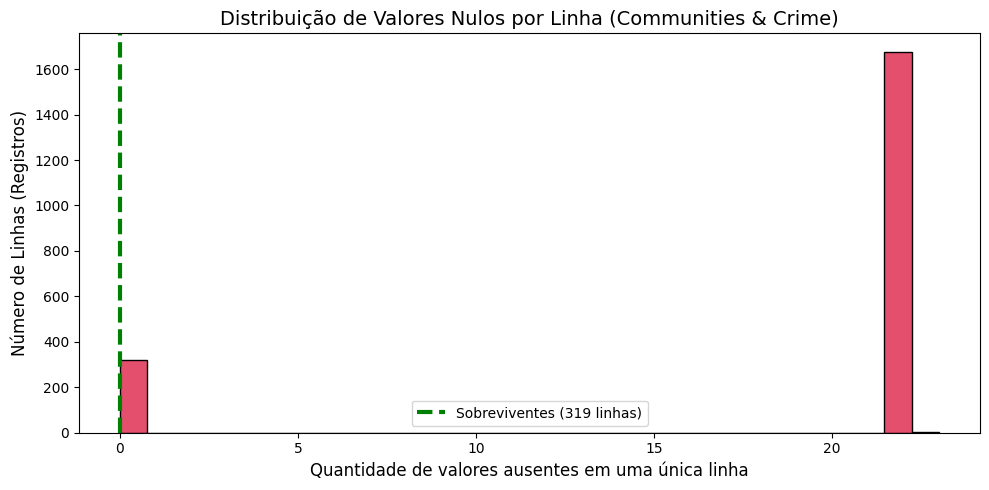

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Carrega exclusivamente o dataset problemático
df_crime, target_crime, _ = load_dataset("communities_crime", data_dir=Path("data"))
df_crime = normalize_missing_values(df_crime)

#df_crime = jenga_inject(df_crime.drop(columns=[target_crime]), mecanism="MCAR", percent=0.2).join(df_crime[target_crime])
# Protege a variável alvo (target) conforme o seu protocolo
df_crime = df_crime.dropna(subset=[target_crime])

print("🕵️‍♂️ RAIO-X DE NULOS: Communities & Crime 🕵️‍♂️")
print(f"Total de linhas: {df_crime.shape[0]}")
print(f"Total de colunas: {df_crime.shape[1]}\n")

# 2. Onde estão os buracos? (Visão por Colunas)
nulos_por_coluna = df_crime.isnull().sum()
cols_com_nulos = nulos_por_coluna[nulos_por_coluna > 0].sort_values(ascending=False)

print("📌 Top 10 colunas com MAIS valores ausentes na base ORIGINAL:")
for col, qtd in cols_com_nulos.head(10).items():
    perc = (qtd / len(df_crime)) * 100
    print(f"   - {col}: {qtd} nulos ({perc:.1f}%)")

# 3. O Vilão do dropna (Visão por Linhas)
nulos_por_linha = df_crime.isnull().sum(axis=1)
linhas_intactas = (nulos_por_linha == 0).sum()

print(f"\n⚠️ IMPACTO DO DROPNA:")
print(f"   - Linhas que sobrevivem (0 nulos): {linhas_intactas}")
print(f"   - Linhas destruídas (pelo menos 1 nulo): {len(df_crime) - linhas_intactas}")

# 4. Visualização do Estrago
plt.figure(figsize=(10, 5))
sns.histplot(nulos_por_linha, bins=30, kde=False, color='crimson')
plt.title("Distribuição de Valores Nulos por Linha (Communities & Crime)", fontsize=14)
plt.xlabel("Quantidade de valores ausentes em uma única linha", fontsize=12)
plt.ylabel("Número de Linhas (Registros)", fontsize=12)

# Destaca a única condição onde o dropna deixa a linha viva
plt.axvline(x=0, color='green', linewidth=3, linestyle='--', label=f'Sobreviventes ({linhas_intactas} linhas)')
plt.legend()
plt.tight_layout()
plt.show()

🕵️‍♂️ RAIO-X DE NULOS: Communities & Crime 🕵️‍♂️
Total de linhas: 1994
Total de colunas: 123

📌 Top 10 colunas com MAIS valores ausentes na base ORIGINAL:
   - col_122: 1758 nulos (88.2%)
   - col_123: 1748 nulos (87.7%)
   - col_126: 1747 nulos (87.6%)
   - col_102: 1746 nulos (87.6%)
   - col_109: 1746 nulos (87.6%)
   - col_110: 1741 nulos (87.3%)
   - col_116: 1740 nulos (87.3%)
   - col_103: 1740 nulos (87.3%)
   - col_117: 1739 nulos (87.2%)
   - col_124: 1738 nulos (87.2%)

⚠️ IMPACTO DO DROPNA:
   - Linhas que sobrevivem (0 nulos): 0
   - Linhas destruídas (pelo menos 1 nulo): 1994


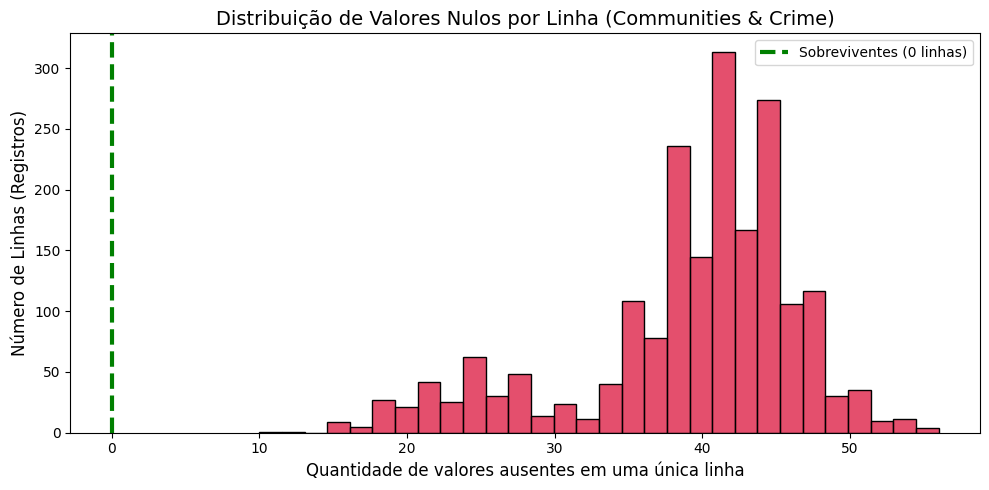

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Carrega exclusivamente o dataset problemático
df_crime, target_crime, _ = load_dataset("communities_crime", data_dir=Path("data"))
df_crime = normalize_missing_values(df_crime)

df_crime = jenga_inject(df_crime.drop(columns=[target_crime]), mecanism="MCAR", percent=0.2).join(df_crime[target_crime])
# Protege a variável alvo (target) conforme o seu protocolo
df_crime = df_crime.dropna(subset=[target_crime])

print("🕵️‍♂️ RAIO-X DE NULOS: Communities & Crime 🕵️‍♂️")
print(f"Total de linhas: {df_crime.shape[0]}")
print(f"Total de colunas: {df_crime.shape[1]}\n")

# 2. Onde estão os buracos? (Visão por Colunas)
nulos_por_coluna = df_crime.isnull().sum()
cols_com_nulos = nulos_por_coluna[nulos_por_coluna > 0].sort_values(ascending=False)

print("📌 Top 10 colunas com MAIS valores ausentes na base ORIGINAL:")
for col, qtd in cols_com_nulos.head(10).items():
    perc = (qtd / len(df_crime)) * 100
    print(f"   - {col}: {qtd} nulos ({perc:.1f}%)")

# 3. O Vilão do dropna (Visão por Linhas)
nulos_por_linha = df_crime.isnull().sum(axis=1)
linhas_intactas = (nulos_por_linha == 0).sum()

print(f"\n⚠️ IMPACTO DO DROPNA:")
print(f"   - Linhas que sobrevivem (0 nulos): {linhas_intactas}")
print(f"   - Linhas destruídas (pelo menos 1 nulo): {len(df_crime) - linhas_intactas}")

# 4. Visualização do Estrago
plt.figure(figsize=(10, 5))
sns.histplot(nulos_por_linha, bins=30, kde=False, color='crimson')
plt.title("Distribuição de Valores Nulos por Linha (Communities & Crime)", fontsize=14)
plt.xlabel("Quantidade de valores ausentes em uma única linha", fontsize=12)
plt.ylabel("Número de Linhas (Registros)", fontsize=12)

# Destaca a única condição onde o dropna deixa a linha viva
plt.axvline(x=0, color='green', linewidth=3, linestyle='--', label=f'Sobreviventes ({linhas_intactas} linhas)')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\felip\AppData\Local\Temp\ipykernel_10428\1920152312.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f'{x*100:.0f}%' for x in plt.gca().get_xticks()]) # Formata o eixo X para %


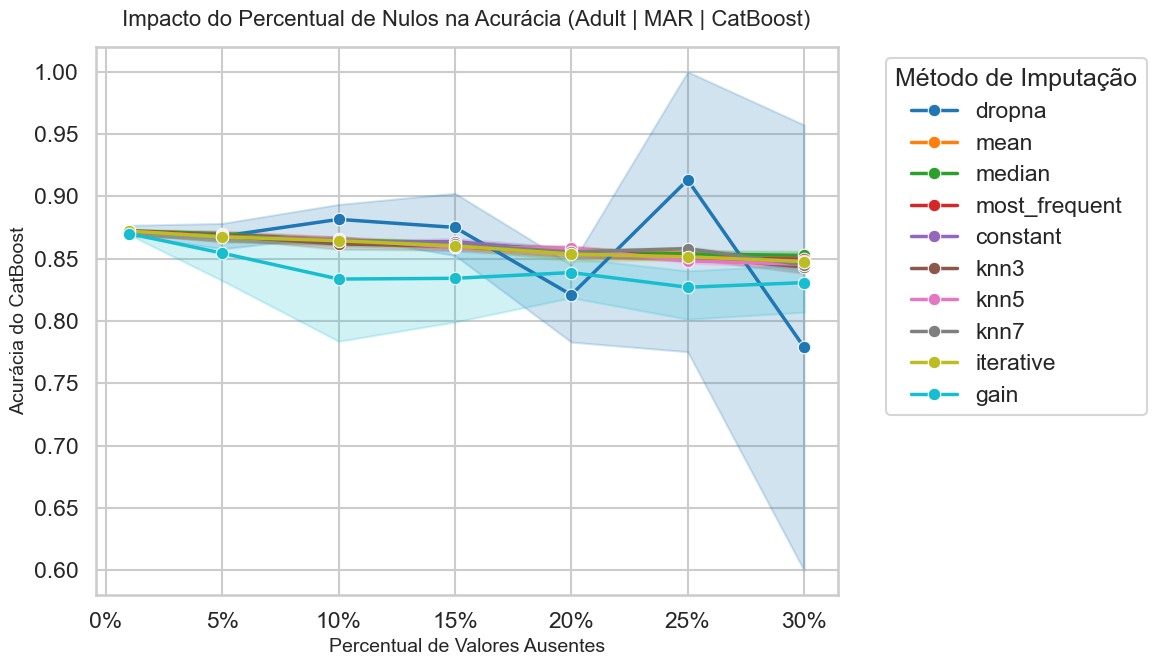

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual premium
sns.set_theme(style="whitegrid", context="talk")
df = pd.read_csv("resultados_experimento_imputacao.csv")

# Filtrando um cenário clássico: Adult (Classificação) sob o mecanismo MAR
df_plot1 = df[(df['dataset'] == 'adult') & (df['mecanismo'] == 'MAR')]

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df_plot1, 
    x='percentual', 
    y='CatBoost_Class_acc', # Avaliando o estado da arte
    hue='estrategia',
    marker='o',
    linewidth=2.5,
    palette='tab10'
)

plt.title('Impacto do Percentual de Nulos na Acurácia (Adult | MAR | CatBoost)', fontsize=16, pad=15)
plt.xlabel('Percentual de Valores Ausentes', fontsize=14)
plt.ylabel('Acurácia do CatBoost', fontsize=14)
plt.legend(title='Método de Imputação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().set_xticklabels([f'{x*100:.0f}%' for x in plt.gca().get_xticks()]) # Formata o eixo X para %
plt.tight_layout()
plt.show()

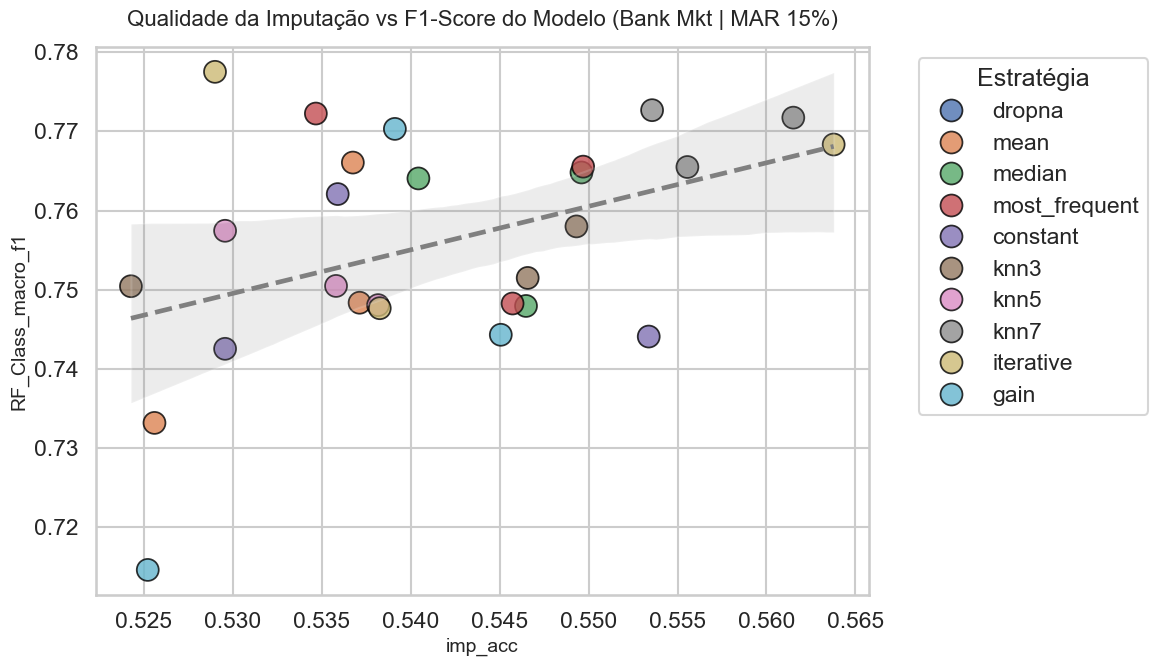

In [16]:
plt.figure(figsize=(12, 7))

# Filtrando o Bank Marketing (MAR, 15% nulos)
df_plot3 = df[(df['dataset'] == 'bank_marketing') & (df['mecanismo'] == 'MAR') & (df['percentual'] == 0.15)]

sns.scatterplot(
    data=df_plot3, 
    x='imp_acc',          # Acurácia de Imputação (Gabarito do Jenga)
    y='RF_Class_macro_f1', # Macro F1 do Random Forest
    hue='estrategia',
    s=250, # Tamanho das bolhas
    alpha=0.8,
    edgecolor='black'
)

plt.title('Qualidade da Imputação vs F1-Score do Modelo (Bank Mkt | MAR 15%)', fontsize=16, pad=15)
plt.xlabel('Acurácia da Imputação (Acerto nos dados deletados)', fontsize=14)
plt.ylabel('Macro F1 do Random Forest', fontsize=14)

# Adiciona uma linha de tendência sutil
sns.regplot(data=df_plot3, x='imp_acc', y='RF_Class_macro_f1', scatter=False, color='gray', line_kws={"linestyle":"--"})

plt.legend(title='Estratégia', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

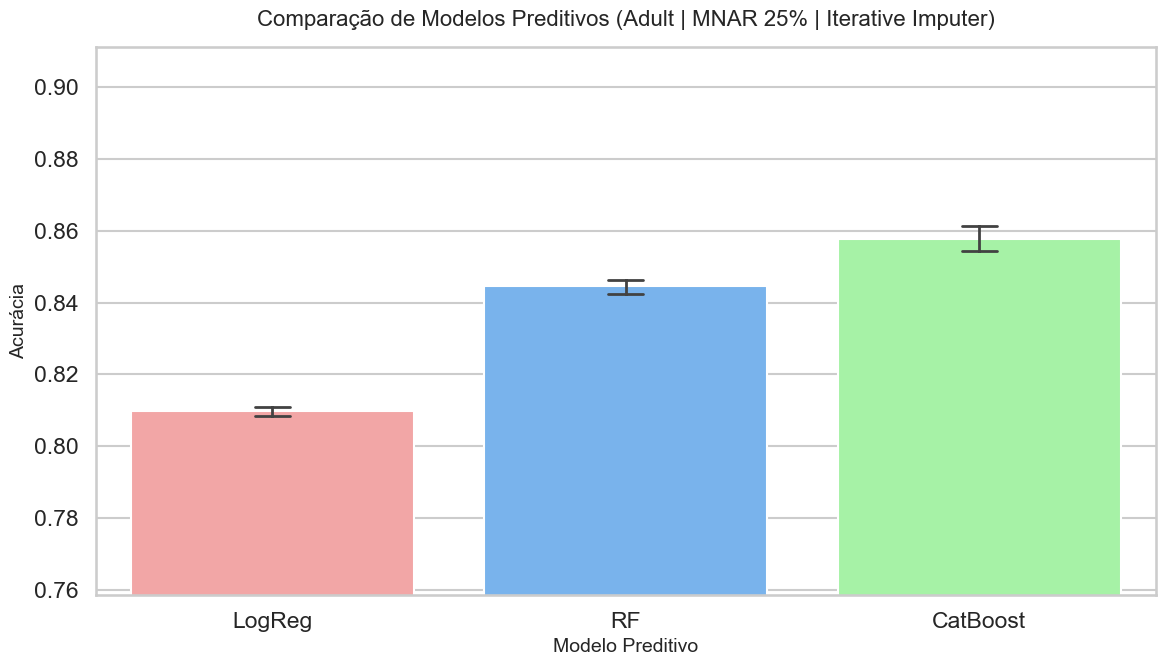

In [17]:
plt.figure(figsize=(12, 7))

# Escolhendo um dataset desafiador, MNAR com 25% de nulos, usando IterativeImputer
df_plot4 = df[(df['dataset'] == 'adult') & (df['mecanismo'] == 'MNAR') & (df['percentual'] == 0.25) & (df['estrategia'] == 'iterative')]

# Derretendo (melt) o dataframe para agrupar os modelos
df_melt = df_plot4.melt(
    id_vars=['semente'], 
    value_vars=['LogReg_acc', 'RF_Class_acc', 'CatBoost_Class_acc'],
    var_name='Modelo', 
    value_name='Acurácia'
)
df_melt['Modelo'] = df_melt['Modelo'].str.replace('_acc', '').str.replace('_Class', '')

sns.barplot(
    data=df_melt, 
    x='Modelo', 
    y='Acurácia',
    hue='Modelo',
    palette=['#ff9999', '#66b3ff', '#99ff99'],
    capsize=0.1,
    err_kws={'linewidth': 2}
)

plt.title('Comparação de Modelos Preditivos (Adult | MNAR 25% | Iterative Imputer)', fontsize=16, pad=15)
plt.xlabel('Modelo Preditivo', fontsize=14)
plt.ylabel('Acurácia', fontsize=14)
# Dar um zoom na diferença cortando a base do eixo Y
bottom_limit = df_melt['Acurácia'].min() - 0.05
plt.ylim(bottom_limit if bottom_limit > 0 else 0, df_melt['Acurácia'].max() + 0.05)
plt.tight_layout()
plt.show()

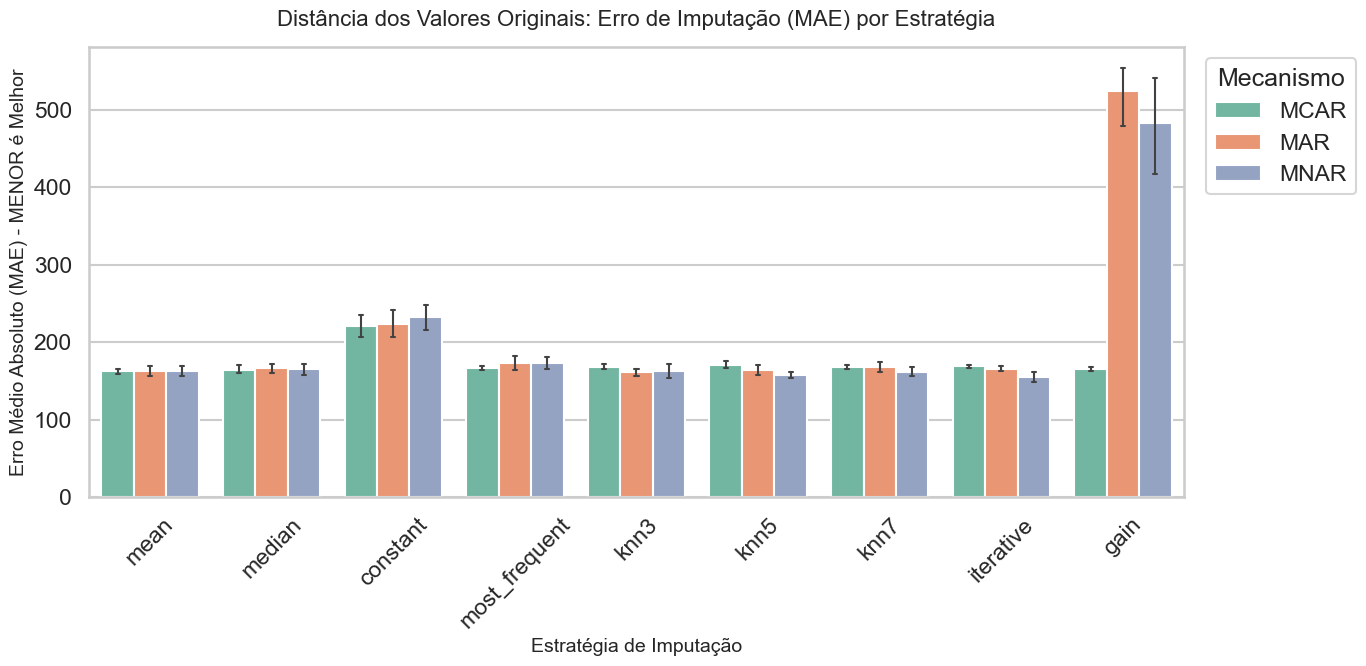

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo
sns.set_theme(style="whitegrid", context="talk")

# Carrega os resultados
df = pd.read_csv("resultados_experimento_imputacao.csv")

# 1. Filtramos um dataset de regressão onde o 'imp_mae' foi calculado.
# Tiramos o baseline (0%) pois ele não tem dados imputados para comparar.
df_erro = df[(df['dataset'] == 'air_quality_uci') & (df['percentual'] > 0)]

# 2. Ordena as estratégias para o gráfico ficar organizado (do mais simples pro mais complexo)
ordem_estrategias = ['mean', 'median', 'constant', 'most_frequent', 'knn3', 'knn5', 'knn7', 'iterative', 'gain']

plt.figure(figsize=(14, 7))

# Criamos um gráfico de barras. O Seaborn automaticamente calcula a média das 3 sementes 
# e coloca a barrinha preta de "margem de erro" (desvio padrão) no topo!
sns.barplot(
    data=df_erro, 
    x='estrategia', 
    y='imp_mae', 
    hue='mecanismo',
    order=ordem_estrategias,
    palette='Set2',
    capsize=0.1,
    err_kws={'linewidth': 1.5}
)

plt.title('Distância dos Valores Originais: Erro de Imputação (MAE) por Estratégia', fontsize=16, pad=15)
plt.xlabel('Estratégia de Imputação', fontsize=14)
plt.ylabel('Erro Médio Absoluto (MAE) - MENOR é Melhor', fontsize=14)

# Rotaciona os nomes no eixo X para não ficarem encavalados
plt.xticks(rotation=45)
plt.legend(title='Mecanismo', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\felip\AppData\Local\Temp\ipykernel_10428\3522465208.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f'{x*100:.0f}%' for x in plt.gca().get_xticks()])


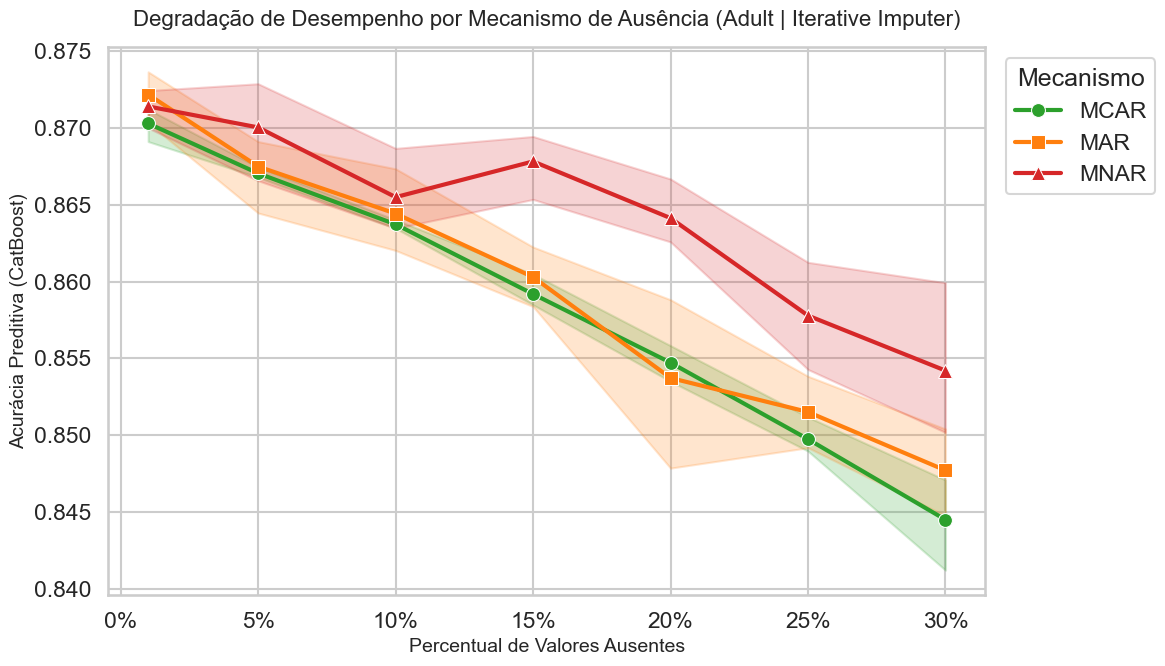

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual premium
sns.set_theme(style="whitegrid", context="talk")

# Carrega os resultados
df = pd.read_csv("resultados_experimento_imputacao.csv")

# 1. Filtramos o dataset 'adult', usando uma estratégia forte (iterative)
# para ver como a dificuldade puramente do mecanismo afeta a predição.
# Ignoramos o percentual 0 (baseline) para o gráfico focar só na injeção.
df_mec = df[(df['dataset'] == 'adult') & 
            (df['estrategia'] == 'iterative') & 
            (df['percentual'] > 0)]

plt.figure(figsize=(12, 7))

# 2. Desenhamos as três linhas (uma para cada mecanismo)
sns.lineplot(
    data=df_mec, 
    x='percentual', 
    y='CatBoost_Class_acc', # Usando a acurácia do CatBoost
    hue='mecanismo',
    style='mecanismo',
    markers=['o', 's', '^'], # Bolinha, Quadrado e Triângulo
    dashes=False,
    linewidth=3,
    palette=['#2ca02c', '#ff7f0e', '#d62728'], # Verde (MCAR), Laranja (MAR), Vermelho (MNAR)
    markersize=10
)

plt.title('Degradação de Desempenho por Mecanismo de Ausência (Adult | Iterative Imputer)', fontsize=16, pad=15)
plt.xlabel('Percentual de Valores Ausentes', fontsize=14)
plt.ylabel('Acurácia Preditiva (CatBoost)', fontsize=14)

# Formata o eixo X para aparecer como porcentagem
plt.gca().set_xticklabels([f'{x*100:.0f}%' for x in plt.gca().get_xticks()])

plt.legend(title='Mecanismo', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

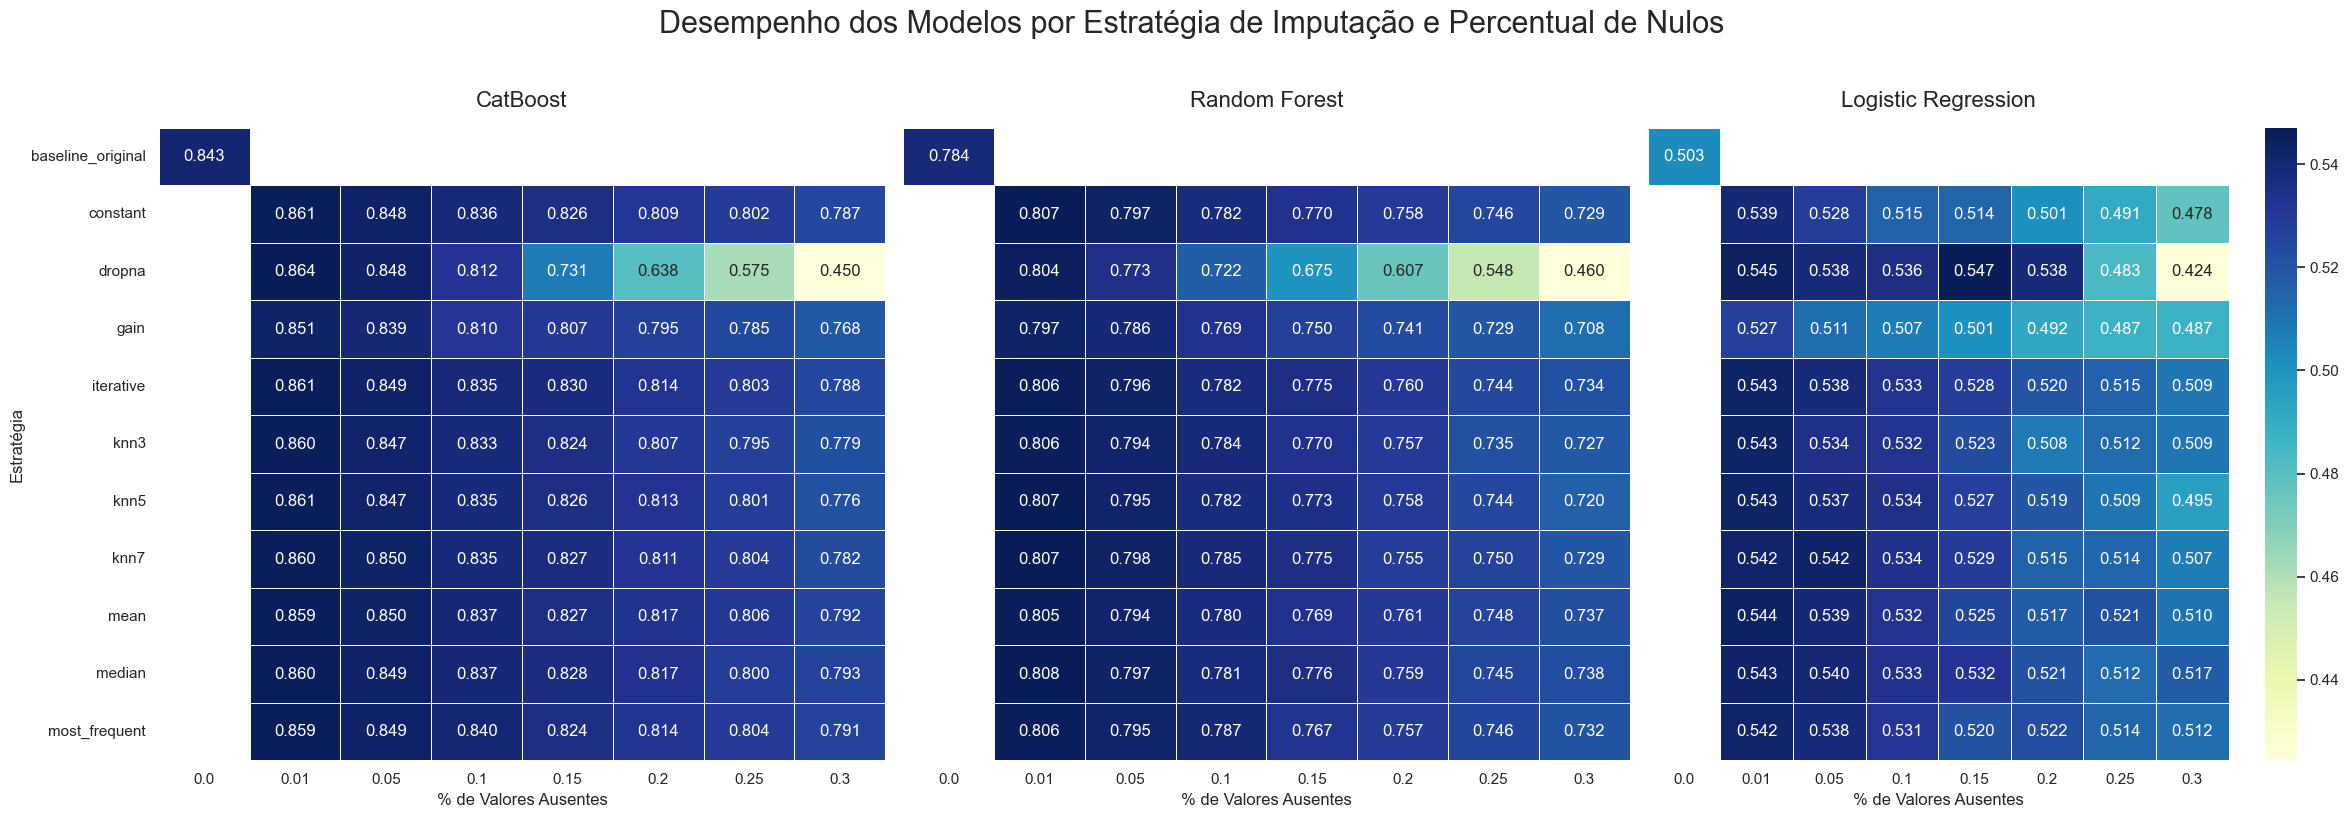

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================= LOAD =================
df = pd.read_csv("resultados_experimento_imputacao.csv")

# ================= MODELOS =================
modelos = {
    'CatBoost': 'CatBoost_Class_macro_f1',
    'Random Forest': 'RF_Class_macro_f1',
    'Logistic Regression': 'LogReg_macro_f1'
}

# ================= ESTILO =================
sns.set_theme(style="white")

# ================= FIGURA =================
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    sharey=True
)

# ================= LOOP =================
for ax, (nome_modelo, coluna) in zip(axes, modelos.items()):

    # pivot
    pivot = df.pivot_table(
        values=coluna,
        index='estrategia',
        columns='percentual',
        aggfunc='mean'
    )

    # heatmap
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        linewidths=0.5,
        cbar=ax == axes[-1],  # colorbar só no último
        ax=ax
    )

    # títulos
    ax.set_title(
        nome_modelo,
        fontsize=16,
        pad=15
    )

    ax.set_xlabel(
        '% de Valores Ausentes',
        fontsize=12
    )

    ax.set_ylabel(
        'Estratégia' if ax == axes[0] else '',
        fontsize=12
    )

    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

# ================= TÍTULO GERAL =================
fig.suptitle(
    'Desempenho dos Modelos por Estratégia de Imputação e Percentual de Nulos',
    fontsize=22,
    y=1.02
)

# ================= AJUSTE =================
plt.tight_layout()

plt.show()

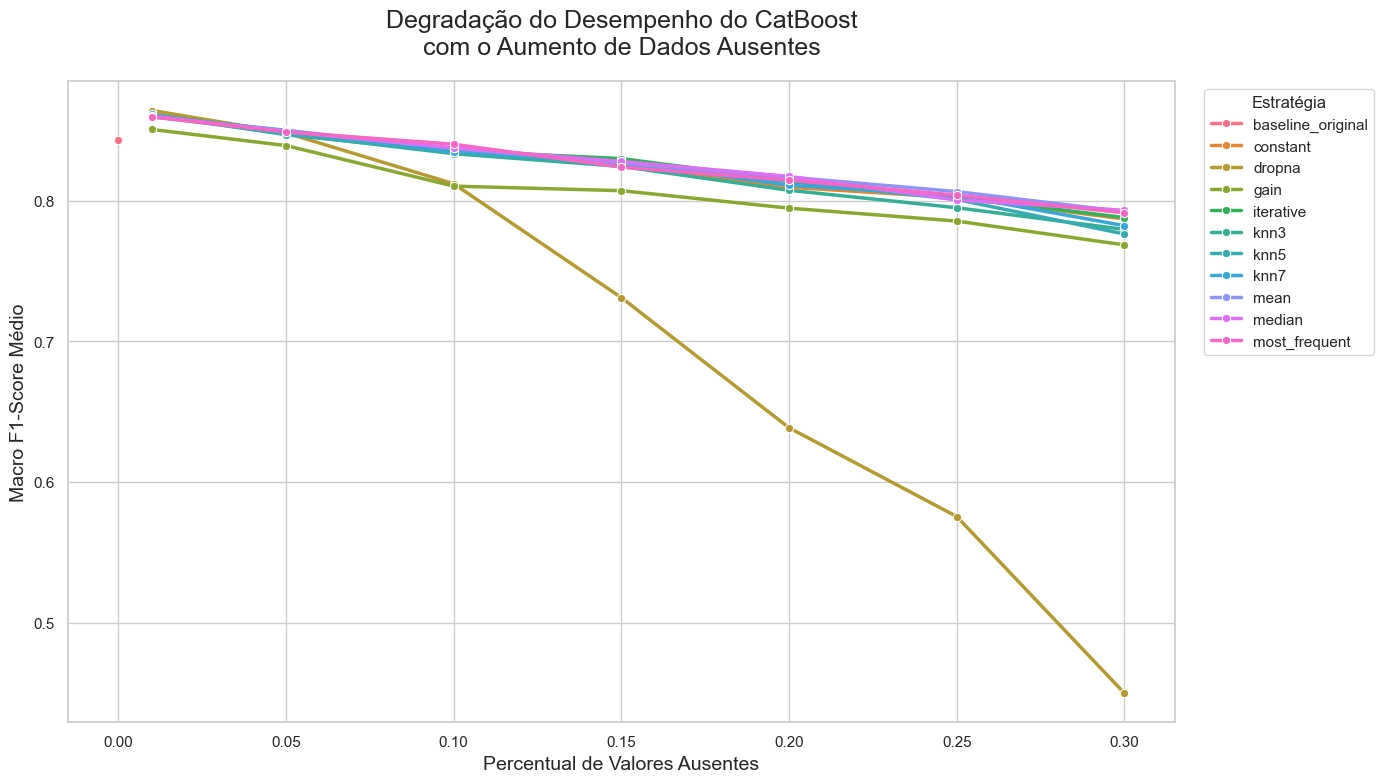

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================= LOAD =================
df = pd.read_csv("resultados_experimento_imputacao.csv")

# ================= AGREGAÇÃO =================
df_plot = (
    df.groupby(['percentual', 'estrategia'])['CatBoost_Class_macro_f1']
    .mean()
    .reset_index()
)

# ================= ESTILO =================
sns.set_theme(style="whitegrid")

# ================= FIGURA =================
plt.figure(figsize=(14, 8))

# ================= LINEPLOT =================
sns.lineplot(
    data=df_plot,
    x='percentual',
    y='CatBoost_Class_macro_f1',
    hue='estrategia',
    marker='o',
    linewidth=2.5
)

# ================= TÍTULOS =================
plt.title(
    'Degradação do Desempenho do CatBoost\ncom o Aumento de Dados Ausentes',
    fontsize=18,
    pad=20
)

plt.xlabel(
    'Percentual de Valores Ausentes',
    fontsize=14
)

plt.ylabel(
    'Macro F1-Score Médio',
    fontsize=14
)

# ================= LEGENDA =================
plt.legend(
    title='Estratégia',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# ================= AJUSTES =================
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()

plt.show()

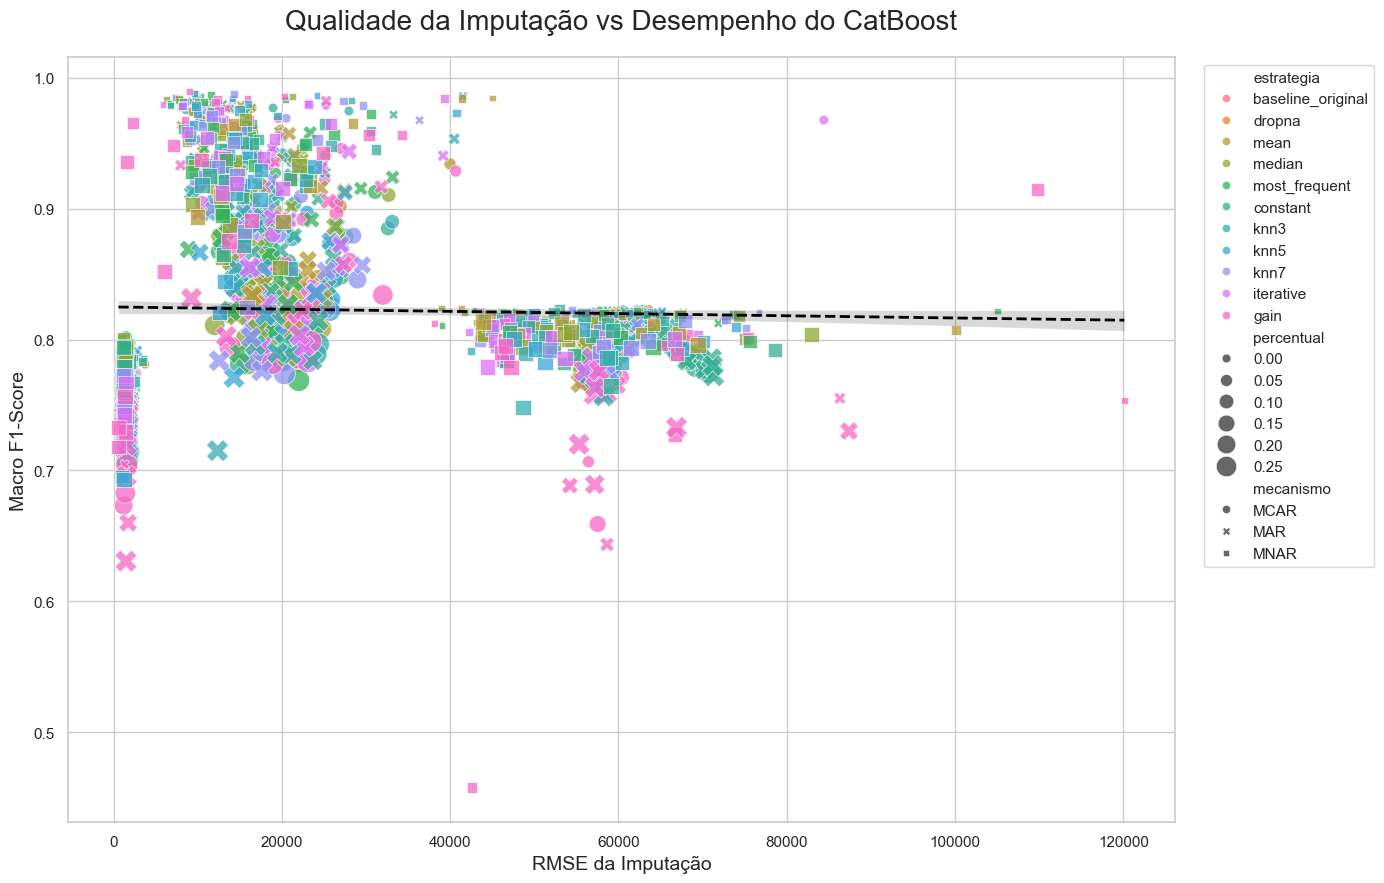

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================= LOAD =================
df = pd.read_csv("resultados_experimento_imputacao.csv")

# ================= ESTILO =================
sns.set_theme(style="whitegrid")

# ================= FIGURA =================
plt.figure(figsize=(14, 9))

# ================= SCATTER =================
sns.scatterplot(
    data=df,
    x='imp_rmse',
    y='CatBoost_Class_macro_f1',
    hue='estrategia',
    style='mecanismo',
    size='percentual',
    sizes=(40, 250),
    alpha=0.75
)

# ================= REGRESSÃO =================
sns.regplot(
    data=df,
    x='imp_rmse',
    y='CatBoost_Class_macro_f1',
    scatter=False,
    color='black',
    line_kws={'linewidth': 2, 'linestyle': '--'}
)

# ================= TÍTULOS =================
plt.title(
    'Qualidade da Imputação vs Desempenho do CatBoost',
    fontsize=20,
    pad=20
)

plt.xlabel(
    'RMSE da Imputação',
    fontsize=14
)

plt.ylabel(
    'Macro F1-Score',
    fontsize=14
)

# ================= LEGENDA =================
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# ================= AJUSTES =================
plt.tight_layout()

plt.show()

In [35]:
import plotly.express as px
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fig = px.scatter(
    df,
    x='imp_rmse',
    y='CatBoost_Class_macro_f1',
    color='estrategia',
    symbol='mecanismo',
    size='percentual',
    hover_data=['dataset'],
    title='Qualidade da Imputação vs Performance do Modelo (CatBoost Macro F1)',
)

fig.show()

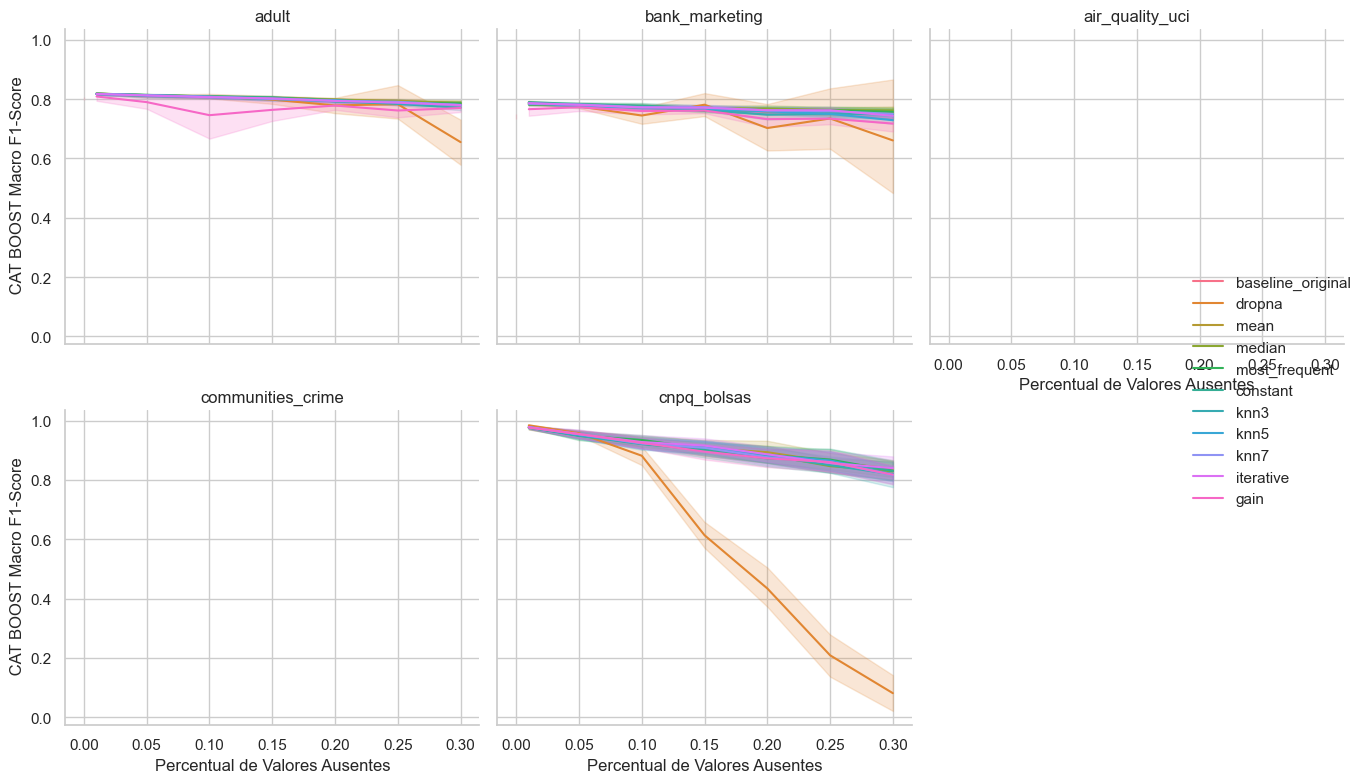

In [34]:
df = pd.read_csv("resultados_experimento_imputacao.csv")

g = sns.FacetGrid(
    df,
    col="dataset",
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.lineplot,
    x="percentual",
    y="CatBoost_Class_macro_f1",
    hue="estrategia"
)

g.add_legend()
g.set_axis_labels("Percentual de Valores Ausentes", " CAT BOOST Macro F1-Score")
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()

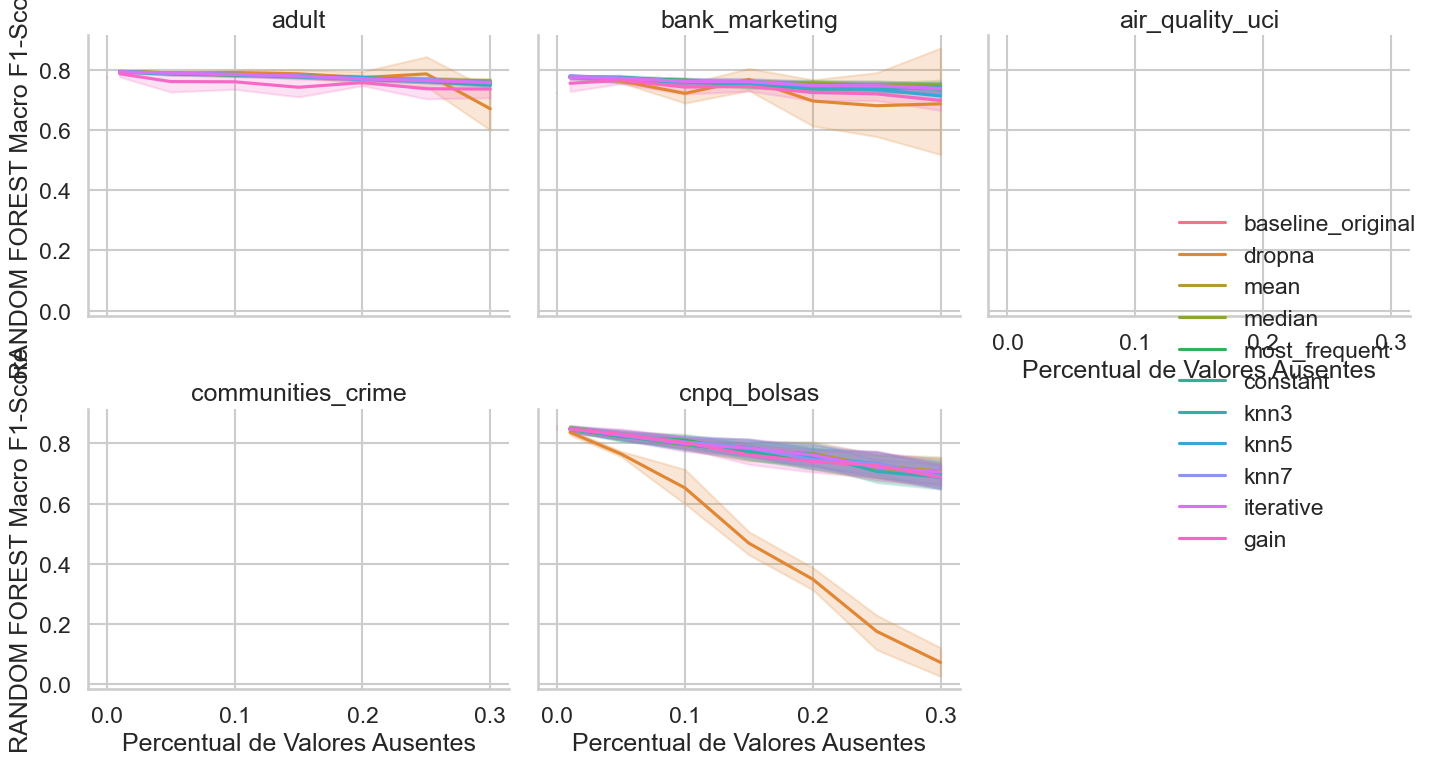

In [54]:
df = pd.read_csv("resultados_experimento_imputacao.csv")

g = sns.FacetGrid(
    df,
    col="dataset",
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.lineplot,
    x="percentual",
    y="RF_Class_macro_f1",
    hue="estrategia"
)

g.add_legend()
g.set_axis_labels("Percentual de Valores Ausentes", "RANDOM FOREST Macro F1-Score")
g
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()

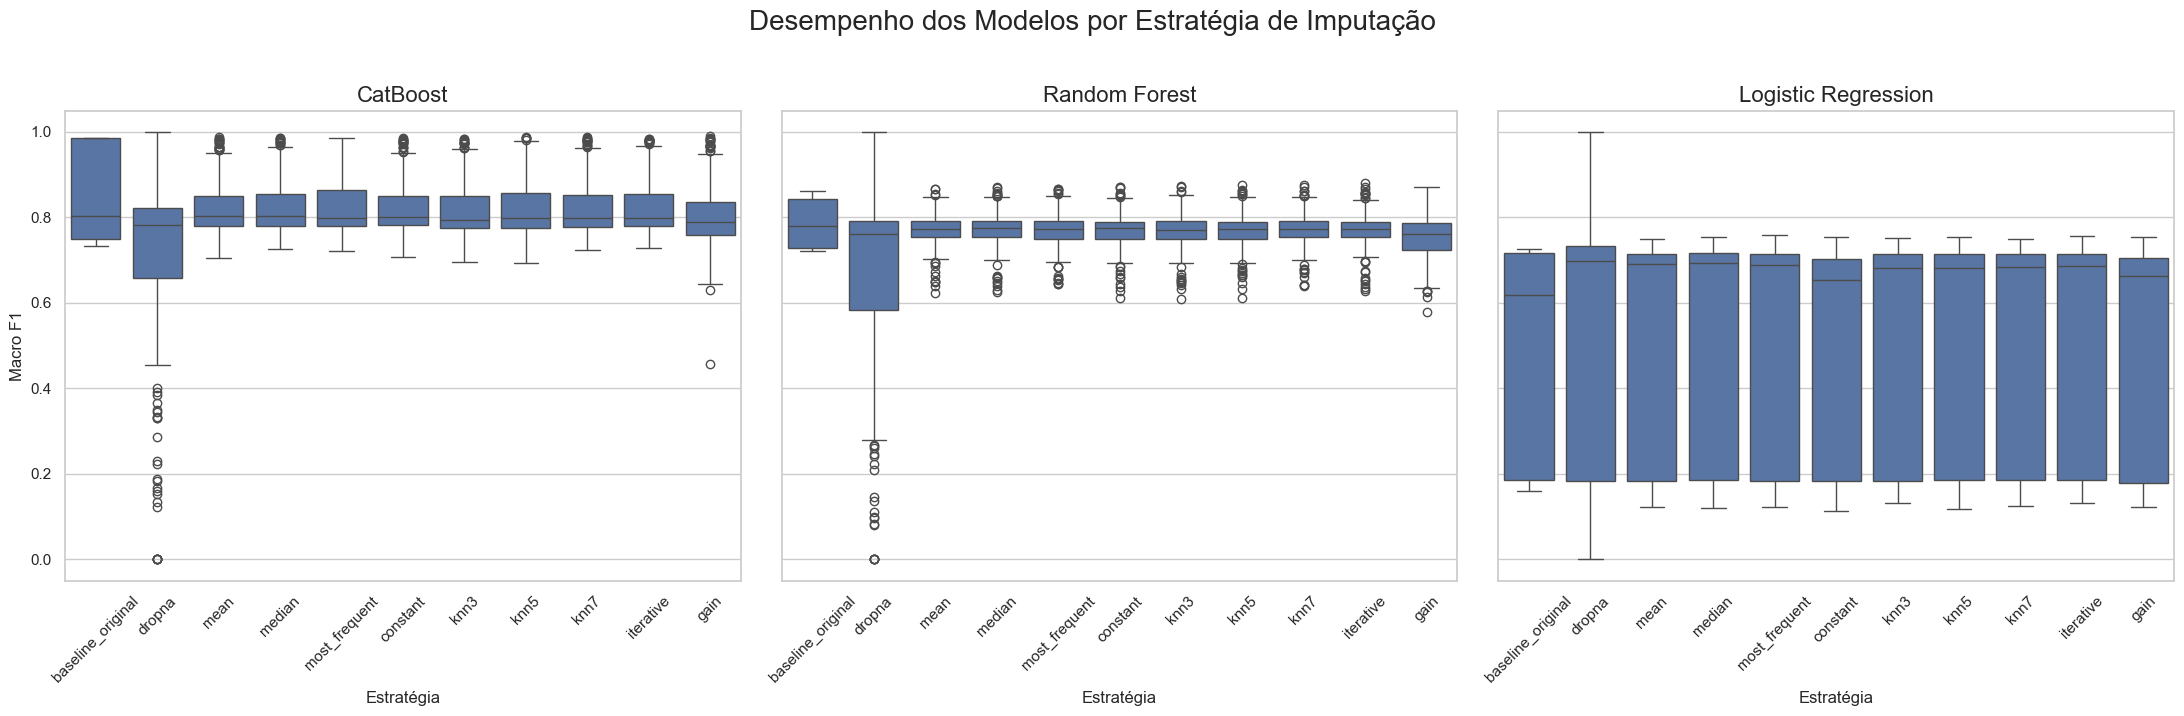

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================= LOAD =================
df = pd.read_csv("resultados_experimento_imputacao.csv")

# ================= ESTILO =================
sns.set_theme(style="whitegrid")

# ================= SUBPLOTS =================
fig, axes = plt.subplots(
    1, 3,
    figsize=(22, 7),
    sharey=True
)

# ================= CATBOOST =================
sns.boxplot(
    data=df,
    x='estrategia',
    y='CatBoost_Class_macro_f1',
    ax=axes[0]
)

axes[0].set_title('CatBoost', fontsize=16)
axes[0].set_xlabel('Estratégia')
axes[0].set_ylabel('Macro F1')

# ================= RANDOM FOREST =================
sns.boxplot(
    data=df,
    x='estrategia',
    y='RF_Class_macro_f1',
    ax=axes[1]
)

axes[1].set_title('Random Forest', fontsize=16)
axes[1].set_xlabel('Estratégia')
axes[1].set_ylabel('')

# ================= LOGISTIC REGRESSION =================
sns.boxplot(
    data=df,
    x='estrategia',
    y='LogReg_macro_f1',
    ax=axes[2]
)

axes[2].set_title('Logistic Regression', fontsize=16)
axes[2].set_xlabel('Estratégia')
axes[2].set_ylabel('')

# ================= ROTAÇÃO =================
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

# ================= TÍTULO GERAL =================
fig.suptitle(
    'Desempenho dos Modelos por Estratégia de Imputação',
    fontsize=20,
    y=1.02
)

# ================= AJUSTE =================
plt.tight_layout()

plt.show()

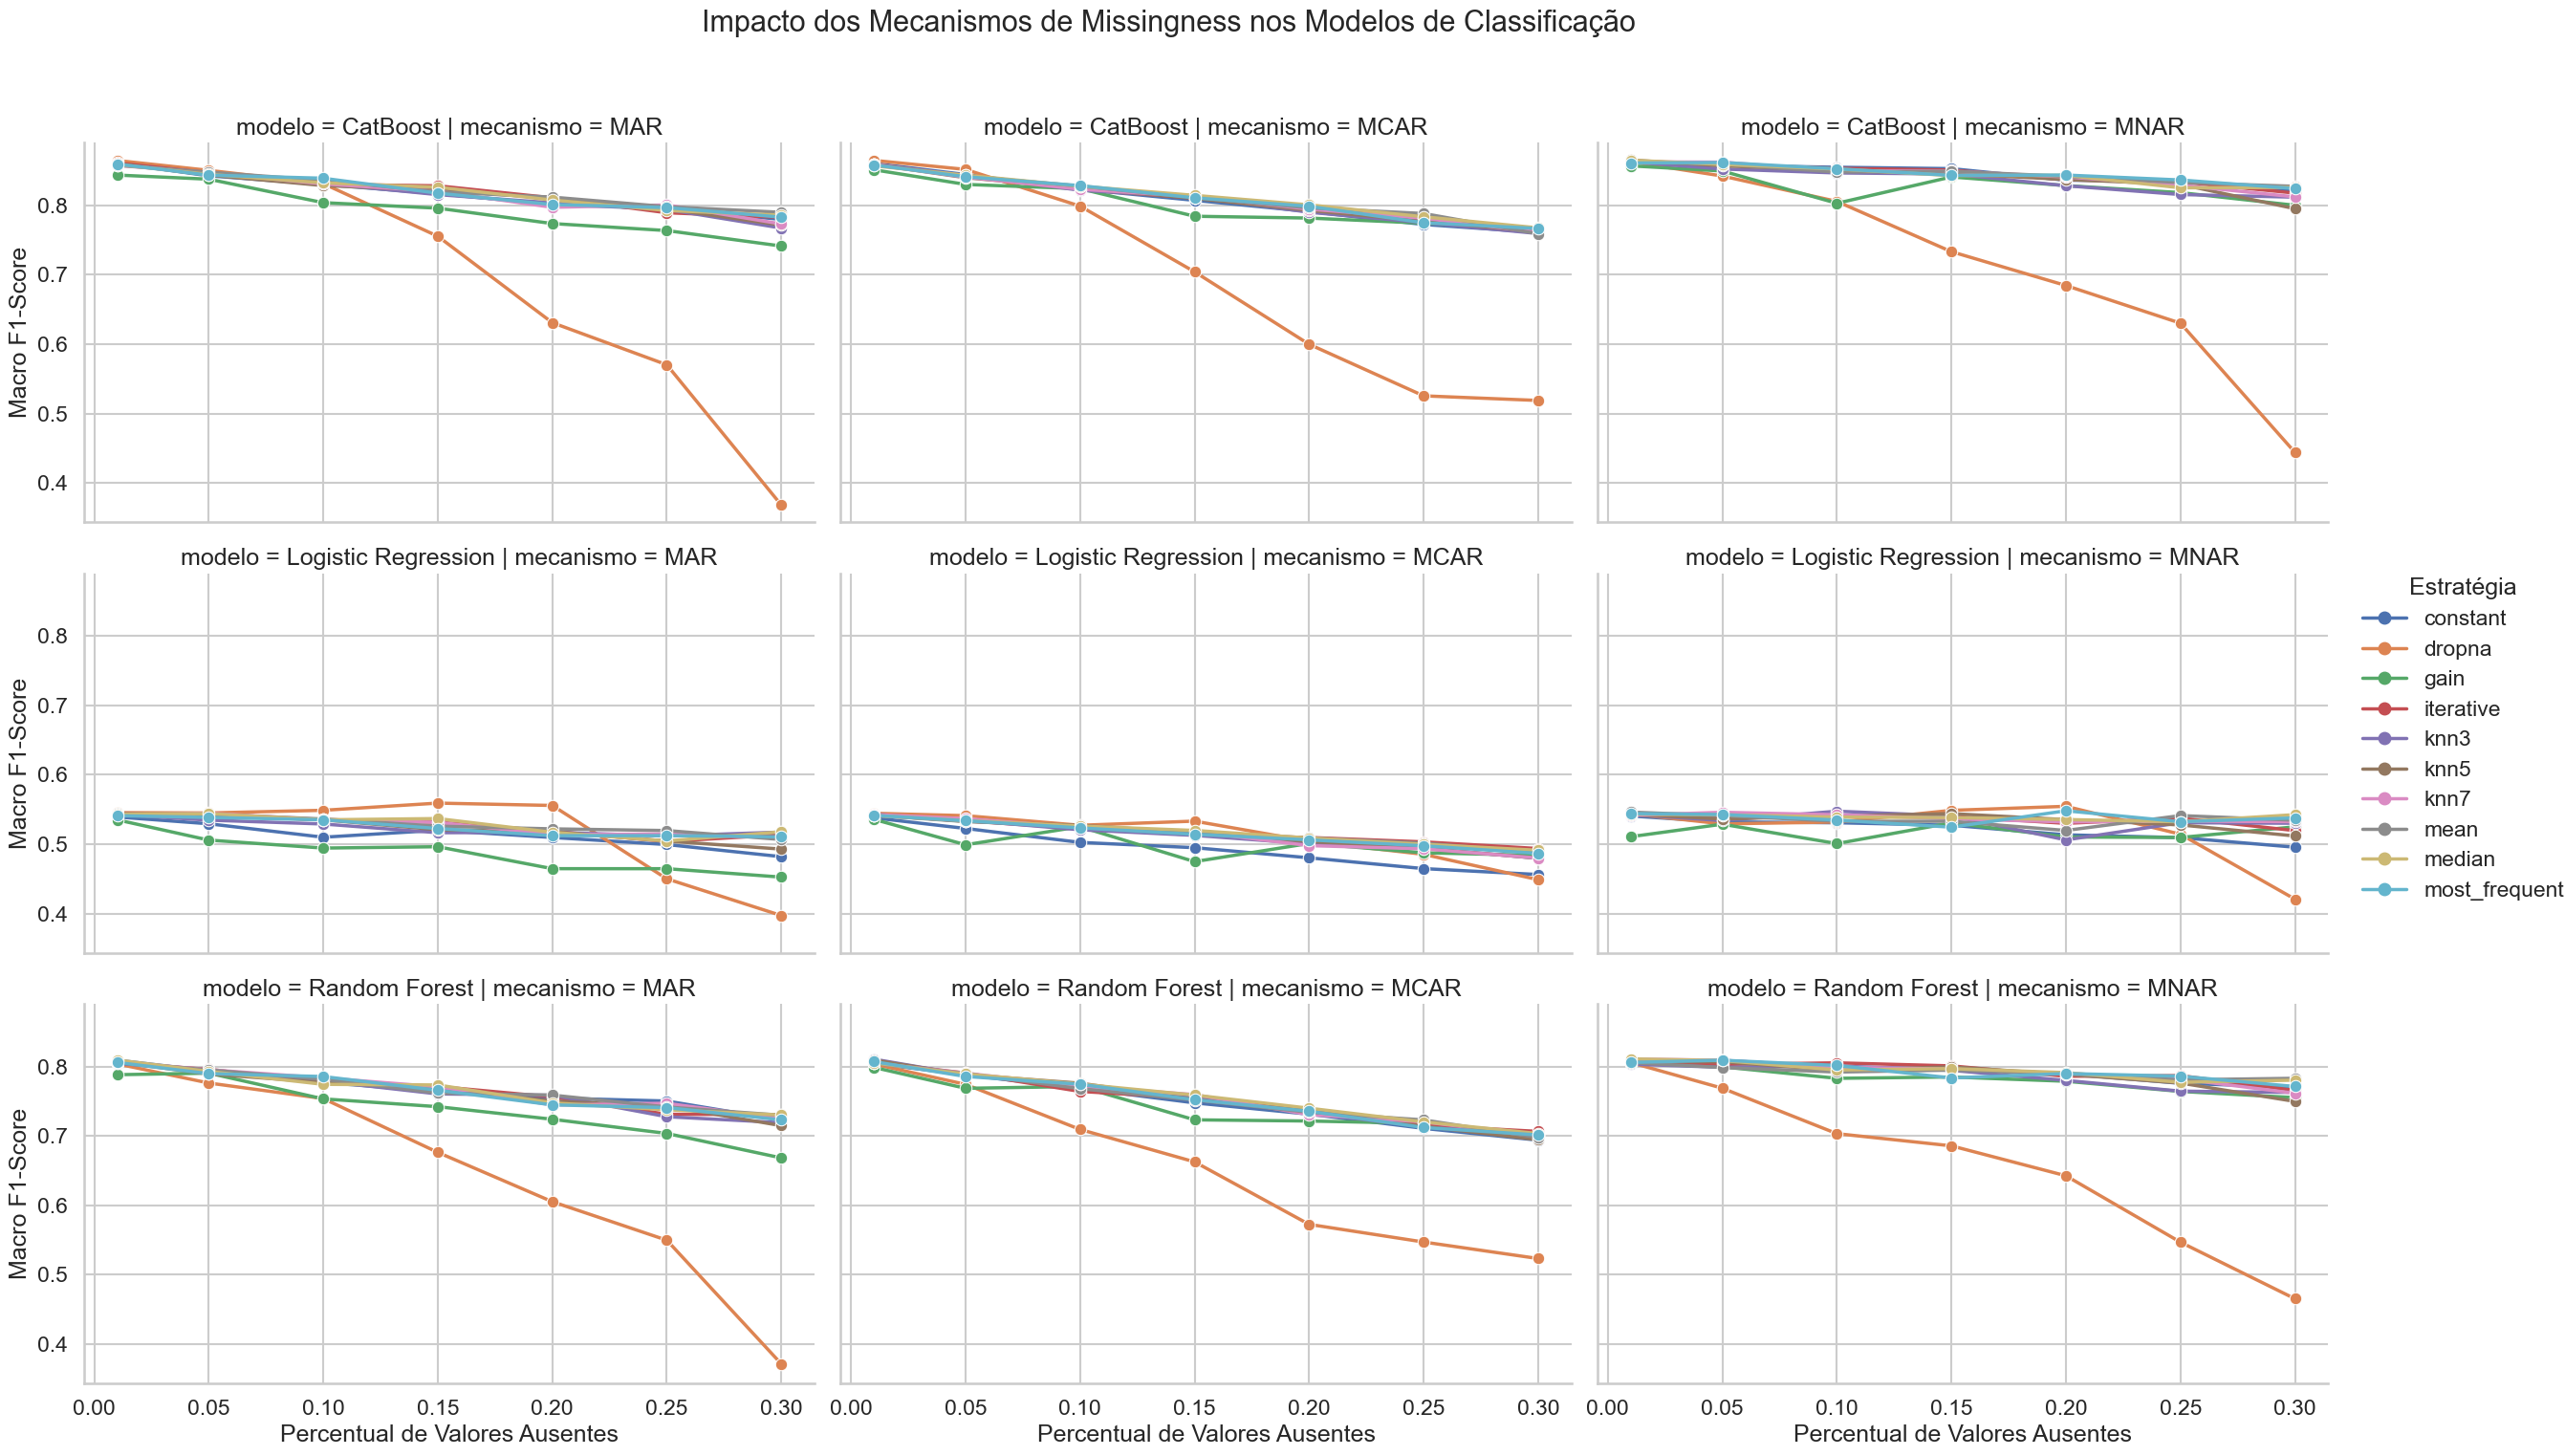

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ================= LOAD =================
df = pd.read_csv("resultados_experimento_imputacao.csv")

# ================= LONG FORMAT =================
df_long = pd.melt(
    df,
    id_vars=[
        'mecanismo',
        'percentual',
        'estrategia'
    ],
    value_vars=[
        'CatBoost_Class_macro_f1',
        'RF_Class_macro_f1',
        'LogReg_macro_f1'
    ],
    var_name='modelo',
    value_name='macro_f1'
)

# ================= RENOMEAR =================
df_long['modelo'] = df_long['modelo'].replace({
    'CatBoost_Class_macro_f1': 'CatBoost',
    'RF_Class_macro_f1': 'Random Forest',
    'LogReg_macro_f1': 'Logistic Regression'
})

# ================= AGREGAÇÃO =================
df_plot = (
    df_long.groupby(
        ['modelo', 'mecanismo', 'percentual', 'estrategia']
    )['macro_f1']
    .mean()
    .reset_index()
)

# ================= ESTILO =================
sns.set_theme(
    style="whitegrid",
    context="talk"
)

# ================= FACETGRID =================
g = sns.relplot(
    data=df_plot,
    x='percentual',
    y='macro_f1',
    hue='estrategia',
    col='mecanismo',
    row='modelo',
    kind='line',
    marker='o',
    linewidth=2.5,
    height=5,
    aspect=1.5
)

# ================= TÍTULO =================
g.fig.suptitle(
    'Impacto dos Mecanismos de Missingness nos Modelos de Classificação',
    fontsize=22,
    y=1.02
)

# ================= RÓTULOS =================
g.set_axis_labels(
    'Percentual de Valores Ausentes',
    'Macro F1-Score'
)

# ================= LEGENDA =================
g._legend.set_title('Estratégia')

g._legend.set_bbox_to_anchor((1.09, 0.5))

g.fig.subplots_adjust(right=2)

# ================= AJUSTES =================
plt.tight_layout()

plt.show()

In [36]:
import pandas as pd
import plotly.express as px

# ================= LOAD =================
df = pd.read_csv("resultados_experimento_imputacao.csv")

# ================= TRANSFORMAR =================
df_long = pd.melt(
    df,
    id_vars=[
        'dataset',
        'estrategia',
        'mecanismo',
        'percentual',
        'imp_rmse'
    ],
    value_vars=[
        'CatBoost_Class_macro_f1',
        'RF_Class_macro_f1',
        'LogReg_macro_f1'
    ],
    var_name='modelo',
    value_name='macro_f1'
)

# ================= RENOMEAR =================
df_long['modelo'] = df_long['modelo'].replace({
    'CatBoost_Class_macro_f1': 'CatBoost',
    'RF_Class_macro_f1': 'Random Forest',
    'LogReg_macro_f1': 'Logistic Regression'
})

# ================= PLOT =================
fig = px.scatter(
    df_long,
    x='imp_rmse',
    y='macro_f1',
    color='estrategia',
    symbol='mecanismo',
    size='percentual',
    facet_col='modelo',
    hover_data=['dataset'],
    title='Qualidade da Imputação vs Performance dos Modelos',
    height=650
)

# ================= ESTILO =================
fig.update_layout(
    title_x=0.5,
    legend_title='Estratégia',
)

fig.show()

In [24]:
import pandas as pd

df, target , task = load_cnpq_bolsas(data_dir=Path("data"))
# quantidade de linha no parquet
print(f"Quantidade de linhas no parquet: {len(df)}")
df.info()

Quantidade de linhas no parquet: 10000
<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1477101 to 2687629
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ano                        10000 non-null  int64  
 1   linha_fomento              10000 non-null  object 
 2   modalidade                 10000 non-null  object 
 3   chamada                    9764 non-null   object 
 4   programa_cnpq              10000 non-null  object 
 5   grande_area_conhecimento   10000 non-null  object 
 6   area_conhecimento          9980 non-null   object 
 7   subarea_conhecimento       10000 non-null  object 
 8   pais_origem                9169 non-null   object 
 9   sigla_uf_origem            9066 non-null   object 
 10  instituicao_origem         9169 non-null   object 
 11  pais_destino               9941 non-null   object 
 12  sigla_uf_destino           9622 non-null   object 
 13  muni